Grand scheme (thesis story)
--------------------------
 We want to reconcile two measurements of feeder/transformer current:
   (1) Janitza at substation transformer level  -> "ground truth-ish" but can be CT-scaled wrong / wiring mixups
   (2) Sum of smart meters on that transformer -> trusted for billing, but incomplete (missing meters, unmetered load, NTL)

 Model (per substation, transformer):
   I_jan(t) = k * I_sm_true(t) + (unmetered + NTL)(t) + noise

 We do NOT observe I_sm_true directly; we observe I_sm_sum and a coverage estimate per_completed.
 So we approximate:
   I_sm_adj(t) = I_sm_sum(t) / per_completed   (coverage-adjusted smart meter current)

 Goal of this notebook:
 1) Clean + align both time series on identical 15-min bins per (substation, transformer)
 2) Estimate k per (substation, transformer) using *low-quantile regression* to fit the lower envelope
    (lower envelope ~ "times when unmetered+NTL is minimal")
 3) Correct Janitza scale by dividing by k
 4) Define Delta(t) = I_jan_corr(t) - I_sm_adj(t) as proxy for unmetered+NTL+mismatch
 5) QC/flag groups where mapping/transformer swap/physics assumptions fail

In [1]:

# Functions + imports
#################################################################################################################
# Core libraries for cleaning, grouping, merging, and quick plots.
# (Note: sklearn LinearRegression imported but not used here; ok to keep for later baseline comparisons.)

import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import math
try:
    import statsmodels.api as sm
    HAVE_SM = True
except Exception as e:
    HAVE_SM = False
    print("statsmodels not available -> will use ratio-quantile fallback.")
    print("Error:", e)   

FREQ = pd.Timedelta(minutes=15)

def parse_dnr(d): 
    """
    'D0411' -> 411
    'D1354' -> 1354
    """
    s = str(d).strip()
    if not s or not s.startswith("D"):
        return None
    digits = s[1:].lstrip("0")  # remove 'D' and leading zeros
    if digits == "":
        return None
    return int(digits)


def make_expected_grid(df, freq=FREQ):
    """Build full expected 15-min grid per (substation, transformer) over its observed span."""
    out = []
    for (sid, tr), g in df.groupby(["substation_id", "transformer"]):
        t0 = g["ts"].min()
        t1 = g["ts"].max()
        grid = pd.date_range(t0, t1, freq=freq)
        out.append(pd.DataFrame({"substation_id": sid, "transformer": tr, "ts": grid}))
    return pd.concat(out, ignore_index=True)


def compute_ct_diagnostics(
    merged: pd.DataFrame,
    min_points: int = 50,
    min_current: float = 5.0,
) -> pd.DataFrame:
    """
    Per-(substation, transformer) diagnostics to detect CT scaling vs unmetered load.

    Expects columns in merged:
      substation_id, transformer, ts,
      I_total_sm, I_total_jn, n_mps, per_completed

    Assumes:
      - Janitza should be an upper bound for true current
        → in a physically consistent situation, I_total_sm <= I_total_jn
        (ignoring noise / mapping mistakes).
    """
    rows = []

    required = {"substation_id", "transformer", "I_total_sm", "I_total_jn"}
    missing = required - set(merged.columns)
    if missing:
        raise KeyError(f"compute_ct_diagnostics: merged is missing required columns: {sorted(missing)}")

    # Normalize transformer just in case
    m = merged.copy()
    m["transformer"] = m["transformer"].astype(str).str.strip().str.lower()

    for (sid, tr), g in m.groupby(["substation_id", "transformer"], dropna=False):
        g = g.copy()

        # Filter out very low currents (ratios get crazy near zero)
        mask = (g["I_total_sm"].abs() > min_current) & (g["I_total_jn"].abs() > min_current)
        g = g[mask]
        if len(g) < min_points:
            continue  # not enough data

        x = g["I_total_sm"].to_numpy()
        y = g["I_total_jn"].to_numpy()

        # --- 1) Physical sanity: how often is SMD > Janitza? ---
        sm_gt_jn = (g["I_total_sm"] > g["I_total_jn"])
        frac_sm_gt_jn = float(sm_gt_jn.mean())

        # --- 2) Unconstrained linear fit: y ≈ alpha * x + beta ---
        alpha_ls, beta = np.polyfit(x, y, 1)

        y_pred = alpha_ls * x + beta
        ss_res = float(np.sum((y - y_pred) ** 2))
        ss_tot = float(np.sum((y - y.mean()) ** 2))
        r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

        # Correlation (shape similarity)
        corr = g["I_total_jn"].corr(g["I_total_sm"])

        # --- 3) Ratio-based view: y/x distribution ---
        ratio = (g["I_total_jn"] / g["I_total_sm"]).replace([np.inf, -np.inf], np.nan).dropna()
        ratio_median = float(ratio.median()) if not ratio.empty else np.nan
        ratio_std = float(ratio.std()) if not ratio.empty else np.nan
        ratio_min = float(ratio.min()) if not ratio.empty else np.nan
        ratio_p05 = float(ratio.quantile(0.05)) if len(ratio) > 0 else np.nan

        # --- 4) "CT scaling" factor under your physical constraint ---
        if float(np.sum(x**2)) > 0:
            alpha0 = float(np.sum(x * y) / np.sum(x**2))
        else:
            alpha0 = np.nan

        alpha_max_phys = ratio_p05  # use ratio_min if you want strict
        if (not np.isnan(alpha0)) and (not np.isnan(alpha_max_phys)):
            alpha_ct = min(alpha0, alpha_max_phys)
        else:
            alpha_ct = np.nan

        # --- 5) Smart-meter completeness & expected alpha from coverage ---
        if "per_completed" in g.columns:
            per_completed = float(pd.to_numeric(g["per_completed"], errors="coerce").max())
            if per_completed > 1.5:  # handle 0–100 scale
                per_completed = per_completed / 100.0
        else:
            per_completed = np.nan

        n_mps = float(pd.to_numeric(g["n_mps"], errors="coerce").max()) if "n_mps" in g.columns else np.nan

        if per_completed and (not np.isnan(per_completed)) and per_completed > 0:
            expected_alpha = 1.0 / per_completed
        else:
            expected_alpha = np.nan

        if (not np.isnan(expected_alpha)) and (not np.isnan(alpha_ct)):
            alpha_over_expected = alpha_ct / expected_alpha
        else:
            alpha_over_expected = np.nan

        rows.append({
            "substation_id": sid,
            "transformer": tr,   # 👈 NEW OUTPUT KEY
            # Unconstrained regression fit (with intercept)
            "alpha_ls": float(alpha_ls),
            "beta": float(beta),
            "r2": float(r2) if not np.isnan(r2) else np.nan,
            "corr": float(corr) if corr is not None else np.nan,
            # Physically constrained CT-like factor
            "alpha_ct": alpha_ct,
            "alpha0_through_origin": alpha0,
            "ratio_min": ratio_min,
            "ratio_p05": ratio_p05,
            "ratio_median": ratio_median,
            "ratio_std": ratio_std,
            # Coverage + expectation
            "per_completed": per_completed,
            "n_mps": n_mps,
            "expected_alpha_from_coverage": expected_alpha,
            "alpha_over_expected": alpha_over_expected,
            # Conservation violation diagnostics
            "frac_sm_gt_jn": frac_sm_gt_jn,
            "n_points": int(len(g)),
        })

    return pd.DataFrame(rows)


def plot_substation_timeseries(merged, sid, alpha=None, max_points=2000):
    g = merged[merged["substation_id"] == sid].sort_values("ts")
    if len(g) > max_points:
        g = g.iloc[:max_points]

    plt.figure(figsize=(12, 4))
    plt.plot(g["ts"], g["I_total_jn"], label="Janitza I_total")
    plt.plot(g["ts"], g["I_total_sm"], label="Smartmeters I_total")

    if alpha is not None:
        plt.plot(g["ts"], alpha * g["I_total_sm"], "--", label=f"SMD * {alpha:.2f}")

    plt.title(f"Substation {sid} – total current")
    plt.xlabel("Time")
    plt.ylabel("Current [A]")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_substation_scatter(merged, sid, transformer=None, alpha=None):
    g = merged[merged["substation_id"] == sid].copy()
    if transformer is not None:
        g = g[g["transformer"].astype(str).str.strip().str.lower() == str(transformer).strip().lower()]

    if g.empty:
        raise ValueError(f"No rows found for substation_id={sid}, transformer={transformer}")

    plt.figure(figsize=(5, 5))
    plt.scatter(g["I_total_sm"], g["I_total_jn"], s=5, alpha=0.3, label="JD vs SMD")

    max_i = max(g["I_total_sm"].max(), g["I_total_jn"].max())
    plt.plot([0, max_i], [0, max_i], "k--", label="JD = SMD")

    if alpha is not None:
        xs = np.linspace(0, max_i, 100)
        plt.plot(xs, alpha * xs, label=f"JD = {alpha:.2f}·SMD")

    plt.xlabel("SMD I_total [A]")
    plt.ylabel("JD I_total [A]")
    tx = f" | {transformer}" if transformer else ""
    plt.title(f"Substation {sid}{tx} – scatter")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_robust_comparison(stats_df, top_n=300):
    """
    Plots MAE (Amps), RMSE (Amps), and WAPE (%) stacked vertically.
    stats_df is indexed by (substation_id, transformer).
    """
    data = stats_df.head(top_n).copy()

    x = np.arange(len(data))
    width = 0.35
    subs = [f"{sid}_{tr}" for (sid, tr) in data.index]  # 👈 nicer labels

    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 14), sharex=True)

    ax1.bar(x - width/2, data["MAE_Before"], width, label='Before (Raw)', color='tab:blue', alpha=0.7)
    ax1.bar(x + width/2, data["MAE_After"], width, label='After (Corrected)', color='tab:green', alpha=0.7)
    ax1.set_ylabel('MAE [Amps]')
    ax1.set_title(f'Mean Absolute Error (MAE) - Top {top_n} (Substation, Trafo)')
    ax1.legend()
    ax1.grid(True, axis='y', alpha=0.3)

    ax2.bar(x - width/2, data["RMSE_Before"], width, label='Before (Raw)', color='tab:blue', alpha=0.7)
    ax2.bar(x + width/2, data["RMSE_After"], width, label='After (Corrected)', color='tab:green', alpha=0.7)
    ax2.set_ylabel('RMSE [Amps]')
    ax2.set_title('Root Mean Square Error (RMSE)')
    ax2.grid(True, axis='y', alpha=0.3)

    ax3.bar(x - width/2, data["WAPE_Before"], width, label='Before (Raw)', color='tab:blue', alpha=0.7)
    ax3.bar(x + width/2, data["WAPE_After"], width, label='After (Corrected)', color='tab:green', alpha=0.7)
    ax3.set_ylabel('WAPE [%]')
    ax3.set_title('Weighted Percentage Error (WAPE)')
    ax3.set_xticks(x)
    ax3.set_xticklabels(subs, rotation=90)
    ax3.grid(True, axis='y', alpha=0.3)

    for i, n in enumerate(data["n_mps"]):
        y_pos = max(data["WAPE_Before"].iloc[i], data["WAPE_After"].iloc[i])
        offset = 0.05 * data["WAPE_Before"].max()
        ax3.text(i, y_pos + offset, f"n={int(n)}", ha='center', fontsize=8, rotation=90)

    plt.tight_layout()
    plt.show()


def plot_substation_timeseries_grid(
    merged: pd.DataFrame,
    summary: pd.DataFrame,
    substation_transformers=None,   # NEW: list of (substation_id, transformer) pairs
    min_per_completed: float = 0.7,
    max_plots: int = 12,
    cols: int = 4,
    max_points: int = 2000,
):
    """
    Grid of time series plots per (substation, transformer).

    For each (substation, transformer):
      - plots Janitza I_total_jn
      - plots Smartmeter I_total_sm
      - if alpha_ct is available in `summary`, also plots alpha_ct * I_total_sm
    """

    # Defensive normalize transformer strings
    merged = merged.copy()
    summary = summary.copy()
    if "transformer" not in merged.columns or "transformer" not in summary.columns:
        raise KeyError("Both merged and summary must contain a 'transformer' column.")

    merged["transformer"] = merged["transformer"].astype(str).str.strip().str.lower()
    summary["transformer"] = summary["transformer"].astype(str).str.strip().str.lower()

    # --- choose which (substation, transformer) pairs to plot ---
    if substation_transformers is not None:
        pairs = [(sid, str(tr).strip().lower()) for sid, tr in list(substation_transformers)[:max_plots]]
        cand = summary.merge(
            pd.DataFrame(pairs, columns=["substation_id", "transformer"]),
            on=["substation_id", "transformer"],
            how="inner",
        )
    else:
        cand = summary[summary["per_completed"] >= min_per_completed].copy()

        # Sort by alpha_over_expected if available, else by (substation_id, transformer)
        if "alpha_over_expected" in cand.columns:
            cand = cand.sort_values("alpha_over_expected", ascending=False)
        else:
            cand = cand.sort_values(["substation_id", "transformer"])

        cand = cand.head(max_plots)

        pairs = list(zip(cand["substation_id"], cand["transformer"]))

    if not pairs:
        print("No (substation, transformer) pairs to plot (check filters or substation_transformers).")
        return

    # Lookup diagnostics by (substation_id, transformer)
    summary_idx = summary.set_index(["substation_id", "transformer"])

    # --- create grid of subplots ---
    n_plots = len(pairs)
    rows = math.ceil(n_plots / cols)

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(6 * cols, 3 * rows),
        sharex=True,
        sharey=False,
    )
    axes = np.array(axes).reshape(-1)

    for ax, (sid, tr) in zip(axes, pairs):
        g = merged[(merged["substation_id"] == sid) & (merged["transformer"] == tr)].sort_values("ts")

        if g.empty:
            ax.set_visible(False)
            continue

        if len(g) > max_points:
            g = g.iloc[:max_points]

        # alpha_ct for this (sid, tr)
        alpha = None
        if "alpha_ct" in summary.columns and (sid, tr) in summary_idx.index:
            alpha_val = summary_idx.loc[(sid, tr), "alpha_ct"]
            try:
                alpha = float(alpha_val)
            except Exception:
                alpha = None

        # Plot original currents
        ax.plot(g["ts"], g["I_total_jn"], label="Janitza I_total")
        ax.plot(g["ts"], g["I_total_sm"], label="Smartmeters I_total")

        # Optional CT-scaled smartmeter line
        if alpha is not None and np.isfinite(alpha):
            ax.plot(g["ts"], alpha * g["I_total_sm"], "--", label=f"SMD × {alpha:.2f}")

        # Title
        title = f"Sub {sid} {tr}"
        if "corr" in summary.columns and (sid, tr) in summary_idx.index:
            try:
                title += f"\nρ={float(summary_idx.loc[(sid, tr), 'corr']):.2f}"
            except Exception:
                pass
        if "per_completed" in summary.columns and (sid, tr) in summary_idx.index:
            try:
                title += f", per={float(summary_idx.loc[(sid, tr), 'per_completed']):.2f}"
            except Exception:
                pass

        ax.set_title(title, fontsize=9)
        ax.set_ylabel("I_total [A]")
        ax.legend(fontsize=8)

    # Hide unused axes
    for ax in axes[n_plots:]:
        ax.set_visible(False)

    # x-label only on bottom row
    for i, ax in enumerate(axes[:n_plots]):
        row_idx = i // cols
        if row_idx == rows - 1:
            ax.set_xlabel("Time")

    fig.suptitle("Transformer total current – JD vs SM (with CT scaling)", y=0.98)
    plt.tight_layout(rect=(0, 0, 1, 0.96))
    plt.show()


def calculate_robust_metrics(df_in, sm_col="I_total_sm", jn_col="I_total_jn", min_current_mape=5.0):
    """
    Calculates row-wise error metrics and aggregates them per (substation_id, transformer).
    Returns a DataFrame indexed by (substation_id, transformer).
    """
    df = df_in.copy()

    # Defensive normalize transformer
    if "transformer" in df.columns:
        df["transformer"] = df["transformer"].astype(str).str.strip().str.lower()
    else:
        raise KeyError("calculate_robust_metrics: df_in must contain a 'transformer' column now.")

    # 1. Basic Difference
    df["diff"] = df[sm_col] - df[jn_col]
    df["abs_diff"] = df["diff"].abs()
    df["sq_diff"] = df["diff"] ** 2

    # 2. Standard MAPE (filtered)
    high_load_mask = df[sm_col] > min_current_mape
    df["mape_filtered"] = np.nan
    df.loc[high_load_mask, "mape_filtered"] = (
        100 * df.loc[high_load_mask, "abs_diff"] / df.loc[high_load_mask, sm_col]
    )

    # 3. SMAPE
    denom = (df[sm_col].abs() + df[jn_col].abs()) / 2
    df["smape"] = 100 * df["abs_diff"] / denom.replace(0, np.nan)

    # --- AGGREGATION (NOW PER substation + transformer) ---
    stats = df.groupby(["substation_id", "transformer"]).agg(
        # Context
        n_points      = (sm_col, "count"),
        n_mps         = ("n_mps", "max"),
        per_completed = ("per_completed", "max"),

        # Absolute Errors (Amps)
        MAE           = ("abs_diff", "mean"),
        RMSE          = ("sq_diff", lambda x: np.sqrt(x.mean())),

        # Percentage Errors
        MAPE_filtered_mean = ("mape_filtered", "mean"),
        SMAPE_mean         = ("smape", "mean"),

        # Sums for WAPE
        sum_abs_diff = ("abs_diff", "sum"),
        sum_sm_total = (sm_col, "sum"),
    )

    stats["WAPE"] = 100 * stats["sum_abs_diff"] / stats["sum_sm_total"].replace(0, np.nan)
    return stats


def plot_scatter_grid(
    merged: pd.DataFrame,
    summary: pd.DataFrame,
    min_per_completed: float = 0.9,
    max_plots: int = 12,
    cols: int = 4,
    min_points: int = 50,
    min_current: float = 5.0,
    normalize: bool = True,
):
    """
    Grid of scatter plots for each (substation_id, transformer):
        x = I_total_sm (smartmeters)
        y = I_total_jn (Janitza)

    When normalize=True, both axes in each subplot are scaled so that
    max(I_total_sm, I_total_jn) for that pair becomes 1.0.
    The slope α is preserved.
    """

    # Basic required cols
    for c in ["substation_id", "transformer", "I_total_sm", "I_total_jn"]:
        if c not in merged.columns:
            raise KeyError(f"merged missing column: {c}")
    for c in ["substation_id", "transformer", "per_completed", "n_points", "alpha_ct", "alpha_over_expected", "r2"]:
        if c not in summary.columns:
            raise KeyError(f"summary missing column: {c}")

    # Normalize transformer strings (defensive)
    merged = merged.copy()
    merged["transformer"] = merged["transformer"].astype(str).str.strip().str.lower()
    summary = summary.copy()
    summary["transformer"] = summary["transformer"].astype(str).str.strip().str.lower()

    # Filter to reasonably complete (substation, transformer) groups
    cand = summary[
        (summary["per_completed"] >= min_per_completed) &
        (summary["n_points"] >= min_points)
    ].copy()

    if cand.empty:
        print("No (substation, transformer) groups meet the per_completed and n_points filters.")
        return

    # Sort so the “worst” ones come first
    cand = cand.sort_values("alpha_over_expected", ascending=False).head(max_plots)

    n_plots = len(cand)
    rows = math.ceil(n_plots / cols)

    fig, axes = plt.subplots(
        rows, cols,
        figsize=(4 * cols, 4 * rows),
        sharex=not normalize,
        sharey=not normalize,
    )
    axes = np.array(axes).reshape(-1)

    # If NOT normalizing, compute global max across selected pairs
    global_max = 0.0
    if not normalize:
        for _, r in cand.iterrows():
            sid = r["substation_id"]
            tr = r["transformer"]
            g = merged[(merged["substation_id"] == sid) & (merged["transformer"] == tr)].copy()
            g = g[(g["I_total_sm"].abs() > min_current) & (g["I_total_jn"].abs() > min_current)]
            if g.empty:
                continue
            local_max = max(g["I_total_sm"].max(), g["I_total_jn"].max())
            global_max = max(global_max, local_max)

        if global_max == 0:
            print("All filtered groups have zero currents after filtering.")
            return

    # Actual plotting
    for ax, (_, row) in zip(axes, cand.iterrows()):
        sid = row["substation_id"]
        tr = row["transformer"]
        alpha = row["alpha_ct"]
        per_completed = row["per_completed"]
        alpha_over_exp = row["alpha_over_expected"]
        r2 = row["r2"]

        g = merged[(merged["substation_id"] == sid) & (merged["transformer"] == tr)].copy()
        g = g[(g["I_total_sm"].abs() > min_current) & (g["I_total_jn"].abs() > min_current)]
        if g.empty:
            ax.set_visible(False)
            continue

        if normalize:
            local_max = max(g["I_total_sm"].max(), g["I_total_jn"].max())
            if local_max == 0:
                ax.set_visible(False)
                continue
            x = g["I_total_sm"] / local_max
            y = g["I_total_jn"] / local_max
            xs = np.linspace(0, 1, 100)
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
        else:
            x = g["I_total_sm"]
            y = g["I_total_jn"]
            xs = np.linspace(0, global_max, 100)
            ax.set_xlim(0, global_max)
            ax.set_ylim(0, global_max)

        ax.scatter(x, y, s=5, alpha=0.3)
        ax.plot(xs, xs, "k--", linewidth=1)                 # JD = SMD
        ax.plot(xs, alpha * xs, linewidth=1)                # JD = alpha * SMD

        ax.set_title(
            f"Sub {sid} {tr}\n"
            f"α={alpha:.2f}, r²={r2:.2f}\n"
            f"per={per_completed:.2f}, α/α_exp={alpha_over_exp:.2f}"
        )

    # Hide unused axes
    for ax in axes[n_plots:]:
        ax.set_visible(False)

    # Axis labels only on outer edges
    for i, ax in enumerate(axes[:n_plots]):
        row_idx = i // cols
        col_idx = i % cols
        if row_idx == rows - 1:
            ax.set_xlabel("I_total_sm (normalized)" if normalize else "I_total_sm [A]")
        if col_idx == 0:
            ax.set_ylabel("I_total_jn (normalized)" if normalize else "I_total_jn [A]")

    plt.suptitle(
        f"JD vs SMD scatter – (substation, trafo) with per_completed ≥ {min_per_completed}",
        y=0.98,
    )
    plt.tight_layout()
    plt.show()


def fit_k_quantile_per_group(df_reg: pd.DataFrame, tau: float = 0.20, min_points: int = 200):
    """
    Fits per-group quantile regression:
      I_total_jn ≈ b + k * I_total_sm_adj
    Returns k_hat and b_hat per (substation_id, transformer) plus QC metrics.

    QC metrics connect to thesis justification:
      - corr_xy, r2_ols: does it look like a strong linear relationship?
      - frac_x_gt_y: how often does SM_adj exceed Janitza? (should be ~0 if mapping/physics OK)
      - frac_neg_resid: how often the fitted model predicts above the data (y < yhat) for a low quantile
    """
    rows = []
    for (sid, tr), g in df_reg.groupby(["substation_id", "transformer"]):
        if len(g) < min_points:
            continue

        x = g["I_total_sm_adj"].to_numpy(dtype=float)
        y = g["I_total_jn"].to_numpy(dtype=float)

        # require positive x for regression stability
        m = np.isfinite(x) & np.isfinite(y) & (x > 0)
        x = x[m]; y = y[m]
        if len(x) < min_points:
            continue

        # --- shape sanity ---
        corr_xy = float(np.corrcoef(x, y)[0, 1]) if len(x) > 1 else np.nan

        # --- physics sanity (raw): how often does SM_adj exceed Janitza? ---
        # This should be near 0 if mapping + scaling are consistent.
        frac_x_gt_y = float(np.mean(x > y))

        per = float(g["per_completed"].iloc[0])

         # Quantile regression with intercept (main diagnostic fit)
        if HAVE_SM:
            X = sm.add_constant(x)  # [1, x]
            try:
                mod = sm.QuantReg(y, X)
                res = mod.fit(q=tau, max_iter=2000)
                b = float(res.params[0])
                k = float(res.params[1])
            except Exception:
                # if solver struggles, fall back to ratio-quantile
                r = y / x
                k = float(np.nanquantile(r, tau))
                b = 0.0
        else:
            # fallback: quantile of ratios (no intercept)
            r = y / x
            k = float(np.nanquantile(r, tau))
            b = 0.0

        # Physics/QC check:
        # For a low quantile fit, residuals should not be massively negative too often.
        yhat = b + k * x
        resid = y - yhat
        frac_neg = float(np.mean(resid < -1e-6))  # tolerance

        # OLS R^2 only for reporting "linearity quality" (NOT used for estimation)
        try:
            k_ols, b_ols = np.polyfit(x, y, 1)
            y_pred = k_ols * x + b_ols
            ss_res = np.sum((y - y_pred)**2)
            ss_tot = np.sum((y - y.mean())**2)
            r2_ols = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan
        except Exception:
            r2_ols = np.nan

        rows.append({
            "substation_id": sid,
            "transformer": tr,
            "tau": tau,
            "k_hat": k,     # slope estimate (CT scaling candidate)
            "b_hat": b,     # intercept estimate (diagnostic; usually not applied in correction)
            "corr_xy": corr_xy,
            "frac_x_gt_y": frac_x_gt_y,
            "per_completed": per,
            "n_points": int(len(x)),
            "frac_neg_resid": frac_neg,
            "r2_ols": r2_ols,
            "k_hat_log10": np.log10(k) if (k is not None and np.isfinite(k) and k > 0) else np.nan,
        })

    return pd.DataFrame(rows).sort_values(["k_hat"], ascending=False)


def detect_transformer_swaps(df_reg, min_points=2000, corr_gain=0.05):
    """
    Transformer swap detection (thesis: "failure mode / data quality diagnostic")
    --------------------------------------------------------------------------
    If substation has both sp1 and sp2, check whether SM_adj(sp1) correlates more
    with Janitza(sp2) than Janitza(sp1) AND likewise SM_adj(sp2) correlates more
    with Janitza(sp1) than Janitza(sp2).

    If both cross-correlations are better by corr_gain -> flag swap_suspect.
    These groups should be excluded or remapped before interpreting k.
    """
    out = []
    need = ["substation_id", "transformer", "ts", "I_total_sm_adj", "I_total_jn"]
    for c in need:
        if c not in df_reg.columns:
            raise KeyError(f"detect_transformer_swaps: df_reg missing {c}")

    for sid, gs in df_reg.groupby("substation_id"):
        trafos = set(gs["transformer"].astype(str).str.lower().unique())
        if not {"sp1", "sp2"}.issubset(trafos):
            continue

        g1 = gs[gs["transformer"].str.lower() == "sp1"][["ts","I_total_sm_adj","I_total_jn"]].rename(
            columns={"I_total_sm_adj":"x1","I_total_jn":"y1"}
        )
        g2 = gs[gs["transformer"].str.lower() == "sp2"][["ts","I_total_sm_adj","I_total_jn"]].rename(
            columns={"I_total_sm_adj":"x2","I_total_jn":"y2"}
        )

        h = g1.merge(g2, on="ts", how="inner")
        if len(h) < min_points:
            continue

        c11 = h["x1"].corr(h["y1"])  # sp1 with sp1
        c22 = h["x2"].corr(h["y2"])  # sp2 with sp2
        c12 = h["x1"].corr(h["y2"])  # sp1 with sp2 (cross)
        c21 = h["x2"].corr(h["y1"])  # sp2 with sp1 (cross)

        best_same = np.nanmax([c11, c22])
        best_cross = np.nanmax([c12, c21])

        swap = (c12 > c11 + corr_gain) and (c21 > c22 + corr_gain)

        out.append({
            "substation_id": sid,
            "n_points_pair": int(len(h)),
            "corr_sp1": float(c11) if pd.notna(c11) else np.nan,
            "corr_sp2": float(c22) if pd.notna(c22) else np.nan,
            "corr_cross_1to2": float(c12) if pd.notna(c12) else np.nan,
            "corr_cross_2to1": float(c21) if pd.notna(c21) else np.nan,
            "best_same": float(best_same) if pd.notna(best_same) else np.nan,
            "best_cross": float(best_cross) if pd.notna(best_cross) else np.nan,
            "gain_cross_minus_same": float(best_cross - best_same) if pd.notna(best_same) and pd.notna(best_cross) else np.nan,
            "swap_suspect": bool(swap),
        })

    return pd.DataFrame(out).sort_values("gain_cross_minus_same", ascending=False)


def fit_k_no_intercept(df_reg, tau=0.20, min_points=200):
    """
    Fits quantile regression WITHOUT intercept:
      I_total_jn ≈ k0 * I_total_sm_adj
    Often preferred for CT scaling correction because it enforces 0->0 behavior.
    """
    rows = []
    for (sid,tr), g in df_reg.groupby(["substation_id","transformer"]):
        if len(g) < min_points:
            continue
        x = g["I_total_sm_adj"].to_numpy(float)
        y = g["I_total_jn"].to_numpy(float)
        m = np.isfinite(x) & np.isfinite(y) & (x > 0)
        x = x[m]; y = y[m]
        if len(x) < min_points:
            continue

        if HAVE_SM:
            # X is just x, no constant column
            try:
                res = sm.QuantReg(y, x).fit(q=tau, max_iter=2000)
                k0 = float(res.params[0])
            except Exception:
                k0 = float(np.nanquantile(y/x, tau))
        else:
            k0 = float(np.nanquantile(y/x, tau))

        rows.append({"substation_id": sid, "transformer": tr, "tau": tau, "k_hat0": k0, "n_points": len(x)})
    return pd.DataFrame(rows)

#################################################################################################################

In [2]:
## Load + preprocess + align time bins (this is the "make the join trustworthy" section)
#################################################################################################################
sm_current_path = "../data/smartmeter_15min_all_by_transformer_20250801_20251101_['LPQ_Current_L1_AVG', 'LPQ_Current_L2_AVG', 'LPQ_Current_L3_AVG'].parquet"
jn_current_path = "../data/janitza_3phase_I_by_transformer_20250801_0000_20251101_0000.parquet"

# Read raw parquet outputs
df_sm_current = pd.read_parquet(sm_current_path)
df_jn_current = pd.read_parquet(jn_current_path)

# Normalize transformer key to avoid merge failures ("SP1" vs "sp1", whitespace, etc.)
for d in (df_sm_current, df_jn_current):
    if "transformer" in d.columns:
        d["transformer"] = d["transformer"].astype(str).str.strip().str.lower()

# Add numeric substation_id from Janitza naming convention
df_jn_current["substation_id"] = df_jn_current["dnr_str"].map(parse_dnr)

# Optional: exclude known broken substations (manual blacklist)
exclude_dnr = []  # e.g. ["D0303", "D1454","D1554","D1049"]
df_jn_current = df_jn_current[~df_jn_current["dnr_str"].isin(exclude_dnr)].copy()
# =========================================================
# NEW FILTER: Exclude Low-Meter-Count Groups (n_mps <= 2)
# =========================================================
# We calculate max meters seen per group to determine if it's "low meter count"
if "n_mps" in df_sm_current.columns:
    # 1. Identify valid groups
    valid_groups = (
        df_sm_current.groupby(["substation_id", "transformer"])["n_mps"]
        .max()
        .reset_index()
    )
    valid_groups = valid_groups[valid_groups["n_mps"] > 2] # Strict > 2 (so 3 or more)
    
    print(f"Filtering: Keeping {len(valid_groups)} groups with > 2 meters.")
    
    # 2. Filter Smart Meter DataFrame
    df_sm_current = df_sm_current.merge(
        valid_groups[["substation_id", "transformer"]], 
        on=["substation_id", "transformer"], 
        how="inner"
    )
    
    # 3. Filter Janitza DataFrame (to avoid processing irrelevant stations)
    df_jn_current = df_jn_current.merge(
        valid_groups[["substation_id", "transformer"]], 
        on=["substation_id", "transformer"], 
        how="inner"
    )
else:
    print("WARNING: 'n_mps' column missing in Smart Meter data. skipping low-meter filter.")
# =========================================================
# Sort for readability + predictable operations
df_sm_current = df_sm_current.sort_values(["substation_id", "ts"])
df_jn_current = df_jn_current.sort_values(["substation_id", "ts"])

# Timestamp normalization:
# - Smartmeter data typically already timezone-naive
# - Janitza often comes with timezone awareness (UTC); convert and strip tz to compare properly in pandas merges
df_sm_current["ts"] = pd.to_datetime(df_sm_current["ts"])
df_jn_current["ts"] = pd.to_datetime(df_jn_current["ts"], utc=True).dt.tz_localize(None)

# Keep only substations that exist in Janitza (we only regress where both sources exist)
jn_substations = df_jn_current["substation_id"].unique()
df_sm_current = df_sm_current[df_sm_current["substation_id"].isin(jn_substations)].copy()

# Ensure both are datetime (defensive)
df_sm_current["ts"] = pd.to_datetime(df_sm_current["ts"])
df_jn_current["ts"] = pd.to_datetime(df_jn_current["ts"])


# Key alignment fix:
# Janitza timestamps may be slightly offset from exact 15-min boundaries.
# We snap to 15-min bins with tolerance, avoiding "ceil gaps" that create missing bins.
tol = pd.Timedelta(seconds=10)  # small tolerance window

ts_raw = df_jn_current["ts"]
t_floor = ts_raw.dt.floor("15min")
offset = ts_raw - t_floor


# If timestamp is only a few seconds after boundary -> treat as boundary.
# Else snap up (ceil) so bins align with the smartmeter aggregator convention.
df_jn_current["ts"] = t_floor.where(offset <= tol, ts_raw.dt.ceil("15min"))

# Trim both datasets to same end time to avoid trailing bins in one source only
max_ts_sm = df_sm_current["ts"].max()
df_sm_current = df_sm_current[df_sm_current["ts"] < max_ts_sm].copy()
df_jn_current = df_jn_current[df_jn_current["ts"] < max_ts_sm].copy()

# Janitza collisions:
# If Janitza has multiple rows per (substation, transformer, ts) (device-level or exporter duplication),
# we aggregate to one record per bin. Mean is a pragmatic choice here; document in thesis.
num_cols = ["I_a", "I_b", "I_c", "I_total"]
df_jn_current = (
    df_jn_current
    .groupby(["substation_id", "ts", "transformer"], as_index=False)[num_cols]
    .mean()
)

# Define the "comparison universe":
# We only compare bins where Janitza exists (JD-present bins). This avoids blaming smartmeters for missing Janitza buckets.
grid = make_expected_grid(df_jn_current, freq=FREQ)
jn_bins = df_jn_current[["substation_id", "ts", "transformer"]].drop_duplicates()

grid = grid.merge(
    jn_bins.assign(jn_present=1),
    on=["substation_id", "ts", "transformer"],
    how="left"
)
grid["jn_present"] = grid["jn_present"].fillna(0).astype(int)

good_bins = grid[grid["jn_present"] == 1][["substation_id", "ts", "transformer"]]

# Filter both sources to exactly these bins (merge safety + fair comparison)
df_jn_good = df_jn_current.merge(good_bins, on=["substation_id", "ts", "transformer"], how="inner")
df_sm_good = df_sm_current.merge(good_bins, on=["substation_id", "ts", "transformer"], how="inner")

# Sanity: sizes and duplicate key checks (crucial when joins feel scary)
print("Original:", df_jn_current.shape, df_sm_current.shape)
print("Common-bin:", df_jn_good.shape, df_sm_good.shape)

print("Duplicate keys in JN good:", df_jn_good.duplicated(["substation_id", "ts", "transformer"]).sum())
print("Duplicate keys in SM good:", df_sm_good.duplicated(["substation_id", "ts", "transformer"]).sum())

#################################################################################################################


Filtering: Keeping 58 groups with > 2 meters.
Original: (501483, 7) (512256, 9)
Common-bin: (501483, 7) (501483, 9)
Duplicate keys in JN good: 0
Duplicate keys in SM good: 0


In [3]:
# Merge smartmeter + Janitza into one frame (this is the regression input "panel dataset")
#################################################################################################################
# After this merge:
#   Each row = one 15-min bin for one (substation_id, transformer)
#   Contains both currents, coverage metadata, etc.
df_merged = df_sm_good.merge(
    df_jn_good,
    on=["substation_id", "ts","transformer"],
    how="inner",             # intersection only
    suffixes=("_sm", "_jn"),
    validate="one_to_one"    # safety check: raises if keys aren't 1:1
)
# Quick differences (not the final model, but good for debugging & intuition)
for col in ["I_a", "I_b", "I_c", "I_total"]:
    df_merged[f"{col}_diff"] = df_merged[f"{col}_sm"] - df_merged[f"{col}_jn"]

df_merged[["I_a_diff", "I_b_diff", "I_c_diff", "I_total_diff"]].describe()

print("Merged shape:",df_merged.shape)
#################################################################################################################

Merged shape: (501483, 17)


In [4]:
# Coverage adjustment + regression eligibility filters
#################################################################################################################
# Why this cell exists:
# Smartmeter sum is not the true transformer load if meters are missing.
# per_completed approximates fraction of load that is metered.
# We adjust:
#   I_total_sm_adj = I_total_sm / per_completed
# Then we regress Janitza on SM_adj.

# Regression filters:
# - remove low-current points (ratios/quantiles unstable near zero)
# - require good coverage (so slope is less confounded by missing meters)
# - require lots of points per group (stable quantile estimation)
min_current = 5.0
min_per_completed = 0.88
min_points = 6000


df = df_merged.copy()

# Clean per_completed: some sources store as 0-100 (%) rather than 0-1 fraction.
df["per_completed"] = pd.to_numeric(df["per_completed"], errors="coerce")
mask_pct = df["per_completed"] > 1.5
df.loc[mask_pct, "per_completed"] = df.loc[mask_pct, "per_completed"] / 100.0

# Outside (0,1] doesn't make physical sense -> treat as missing
df.loc[(df["per_completed"] <= 0) | (df["per_completed"] > 1.0), "per_completed"] = np.nan

# Coverage-adjusted smartmeter current (proxy for "true metered load")
df["I_total_sm_adj"] = df["I_total_sm"] / df["per_completed"]
df.loc[~np.isfinite(df["I_total_sm_adj"]), "I_total_sm_adj"] = np.nan


df_reg = df[
    (df["I_total_sm"].abs() > min_current) &
    (df["I_total_jn"].abs() > min_current) &
    (df["per_completed"] >= min_per_completed) &
    (df["I_total_sm_adj"] > 0) &
    np.isfinite(df["I_total_sm_adj"]) &
    np.isfinite(df["I_total_jn"])
].copy()

print("df_reg shape:", df_reg.shape)
print("Unique (sub,trafo):", df_reg.groupby(["substation_id","transformer"]).ngroups)

# Sanity: group sizes and how many fail min_points (helps tune thresholds)
gsize = df_reg.groupby(["substation_id", "transformer"]).size().sort_values(ascending=False)
display(gsize.head(10))
print("Groups with < min_points:", (gsize < min_points).sum(), "/", len(gsize))
#################################################################################################################

df_reg shape: (219557, 18)
Unique (sub,trafo): 25


substation_id  transformer
1248           sp1            8832
1364           sp1            8832
411            sp1            8832
537            sp1            8832
579            sp1            8832
670            sp1            8832
1029           sp1            8832
1030           sp1            8832
1049           sp2            8832
1133           sp1            8832
dtype: int64

Groups with < min_points: 0 / 25


In [5]:
# Estimate CT scaling k per (substation, transformer) using low-quantile regression
#################################################################################################################
# Why quantile regression:
# We assume Janitza often includes extra positive components (unmetered + NTL),
# so we fit a LOW quantile (e.g. 10th percentile) to approximate the "lower envelope":
#   y = I_janitza  vs  x = I_sm_adj
# Lower envelope corresponds to periods where unmetered/NTL is minimal,
# so the fitted slope k captures CT scaling better than OLS (which would be pulled upward).

# --- Run estimators + QC views ---
df_k = fit_k_quantile_per_group(df_reg, tau=0.20, min_points=min_points)
print("Estimated k for groups:", len(df_k))

swap_df = detect_transformer_swaps(df_reg, min_points=min_points, corr_gain=0.05)
print("Swap suspects:", int(swap_df["swap_suspect"].sum()))


# Distribution summaries (helps pick plausibility thresholds and find pathological stations)
# Look at distribution of k
#display(df_k[["k_hat","frac_neg_resid","per_completed","n_points"]].describe())
# Top 10 largest k (likely CT/mapping issues)
#display(df_k.sort_values("k_hat", ascending=False).head(10))



# Simple flags:
# bad_shape: relationship isn't strongly linear -> k estimate likely meaningless
# bad_physics: too often SM_adj > Janitza -> mapping swap/coverage issue/etc.
df_k["bad_shape"] = (df_k["corr_xy"] < 0.8) | (df_k["r2_ols"] < 0.8)
df_k["bad_physics"] = (df_k["frac_x_gt_y"] > 0.05)  # tune threshold
display(df_k[df_k["bad_shape"] | df_k["bad_physics"]].sort_values(["bad_physics","bad_shape"], ascending=False).head(30))


# Apply correction using k_hat (intercept fit), then compute Delta proxy
df_corr = df_reg.merge(
    df_k[["substation_id","transformer","k_hat","b_hat"]],
    on=["substation_id","transformer"],
    how="left",
)

# Fill missing k with 1 (no correction) for groups not fitted
df_corr["k_hat"] = df_corr["k_hat"].fillna(1.0)


# Correction step (thesis: "CT scaling correction"):
#   I_jn_corr = I_jn / k_hat
# We do NOT subtract intercept by default; b_hat is treated as diagnostic bias.
df_corr["I_total_jn_corr"] = df_corr["I_total_jn"] / df_corr["k_hat"]

# Residual indicator (thesis: "unmetered + NTL + mismatch proxy"):
#   Delta(t) = I_jn_corr(t) - I_sm_adj(t)
df_corr["Delta"] = df_corr["I_total_jn_corr"] - df_corr["I_total_sm_adj"]

#################################################################################################################

Estimated k for groups: 25
Swap suspects: 0


,substation_id,transformer,tau,k_hat,b_hat,corr_xy,frac_x_gt_y,per_completed,n_points,frac_neg_resid,r2_ols,k_hat_log10,bad_shape,bad_physics
4,579,sp1,0.2,0.805711,-2.188800,0.893944,0.774683,0.886792,8832,0.199955,0.799136,-0.093820,True,True
2,411,sp1,0.2,0.477886,119.443466,0.786395,0.248641,1.000000,8832,0.199841,0.618416,-0.320676,True,True
24,1496,sp1,0.2,1.064385,-21.721596,0.989732,0.082559,1.000000,8830,0.199887,0.979570,0.027099,False,True
16,1379,sp1,0.2,1.027759,1.495550,0.950801,0.080413,0.977273,8817,0.199955,0.904022,0.011891,False,True
13,1354,sp2,0.2,0.928886,2.200608,0.988493,0.785189,0.992509,8831,0.199977,0.977118,-0.032038,False,True
8,1049,sp2,0.2,0.915580,-12.571144,0.986429,0.973732,0.970760,8832,0.199841,0.973042,-0.038304,False,True
5,670,sp1,0.2,0.905442,-11.230467,0.931602,0.651381,0.902357,8832,0.199955,0.867882,-0.043139,False,True
20,1416,sp1,0.2,0.896000,30.969146,0.966185,0.347299,0.985437,8831,0.199977,0.933513,-0.047692,False,True
21,1454,sp1,0.2,0.882053,9.497141,0.980962,0.679302,0.909091,7677,0.199948,0.962286,-0.054505,False,True
10,1248,sp1,0.2,0.826626,0.688211,0.988614,0.999887,0.950000,8832,0.199955,0.977358,-0.082691,False,True


out liear look up

In [6]:
#################################################################################################################
# distribution + outliers
display(df_k["k_hat"].describe())


# Flag "implausible" k for manual inspection / exclusion policy.
# This threshold is a policy decision you will justify in thesis.
k_lo, k_hi = 0.5, 3.0
outliers = df_k[(df_k["k_hat"] < k_lo) | (df_k["k_hat"] > k_hi)].copy()
display(outliers.sort_values("k_hat", ascending=False))

print("n groups:", len(df_k))
print("n outliers:", len(outliers))

# Note: later you will likely combine: swap_suspect + bad_shape + outlier k + high frac_delta_neg -> "exclude"
##################################################################################################################

count    25.000000
mean      1.354873
std       1.814268
min       0.154013
25%       0.837965
50%       1.022578
75%       1.215251
max       9.910214
Name: k_hat, dtype: float64

,substation_id,transformer,tau,k_hat,b_hat,corr_xy,frac_x_gt_y,per_completed,n_points,frac_neg_resid,r2_ols,k_hat_log10,bad_shape,bad_physics
9,1133,sp1,0.2,9.910214,-810.067676,0.995575,0.000000,1.000000,8832,0.199955,0.991169,0.996083,False,False
2,411,sp1,0.2,0.477886,119.443466,0.786395,0.248641,1.000000,8832,0.199841,0.618416,-0.320676,True,True
12,1299,sp1,0.2,0.154013,5.529550,0.951734,1.000000,0.881818,8817,0.199955,0.905798,-0.812443,False,True


n groups: 25
n outliers: 3


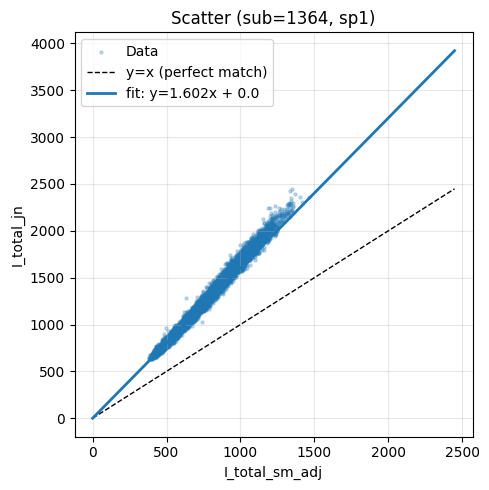

In [9]:
sid, tr = 1364, "sp1"
g = df_reg[(df_reg["substation_id"] == sid) & (df_reg["transformer"] == tr)].copy()
g = g.sort_values("ts")

# Pick which k to show (use your chosen "final" policy)
# Option A: no-intercept k (recommended for CT scaling)
k = float(df_k0.loc[(df_k0.substation_id==sid) & (df_k0.transformer==tr), "k_hat0"].iloc[0])
b = 0.0

# Option B: with intercept (if you want to visualize it too)
# k = float(df_k.loc[(df_k.substation_id==sid) & (df_k.transformer==tr), "k_hat"].iloc[0])
# b = float(df_k.loc[(df_k.substation_id==sid) & (df_k.transformer==tr), "b_hat"].iloc[0])

x = g["I_total_sm_adj"].to_numpy(float)
y = g["I_total_jn"].to_numpy(float)

plt.figure(figsize=(5,5))
plt.scatter(x, y, s=5, alpha=0.25, label="Data")

mx = np.nanmax([np.nanmax(x), np.nanmax(y)])
xs = np.linspace(0, mx, 200)

plt.plot(xs, xs, "k--", lw=1, label="y=x (perfect match)")
plt.plot(xs, b + k*xs, lw=2, label=f"fit: y={k:.3f}x + {b:.1f}")  # <<< THIS IS THE NEW LINE

plt.title(f"Scatter (sub={sid}, {tr})")
plt.xlabel("I_total_sm_adj")
plt.ylabel("I_total_jn")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [8]:
# No-intercept quantile regression variant (candidate final correction slope)
#################################################################################################################
# Why this cell exists:
# Physically, if load is zero, both sensors should read ~0. For CT scaling, a no-intercept slope is often cleaner.
# In practice, intercept can capture bias/offset/noise; but for *scaling correction* we usually want slope-only.
# This cell compares k_hat (with intercept) vs k_hat0 (no intercept) and then applies slope-only correction.

df_k0 = fit_k_no_intercept(df_reg, tau=0.20, min_points=200)

# Compare intercept vs no-intercept slopes (thesis: show they are similar for "good" groups)
df_k_cmp = df_k.merge(df_k0, on=["substation_id", "transformer", "tau"], how="left")
df_k_cmp["k_ratio"] = df_k_cmp["k_hat"] / df_k_cmp["k_hat0"]

display(df_k_cmp.sort_values("k_hat", ascending=False).head(15))
display(df_k_cmp[["k_hat","k_hat0","k_ratio"]].describe())
#################################################################################################################


,substation_id,transformer,tau,k_hat,b_hat,corr_xy,frac_x_gt_y,per_completed,n_points_x,frac_neg_resid,r2_ols,k_hat_log10,bad_shape,bad_physics,k_hat0,n_points_y,k_ratio
0,1133,sp1,0.2,9.910214,-810.067676,0.995575,0.000000,1.000000,8832,0.199955,0.991169,0.996083,False,False,8.904345,8832,1.112964
1,202,sp2,0.2,1.721839,-148.803299,0.977724,0.000000,0.880000,8826,0.199977,0.955944,0.235993,False,False,1.481910,8826,1.161905
2,1364,sp1,0.2,1.678576,-54.384969,0.993884,0.000000,0.994859,8832,0.199955,0.987806,0.224941,False,False,1.602277,8832,1.047619
3,1364,sp2,0.2,1.432233,76.968029,0.879065,0.000000,0.977778,8832,0.199955,0.772755,0.156014,True,False,1.761788,8832,0.812943
4,1029,sp1,0.2,1.247989,-69.442837,0.942600,0.010983,0.930233,8832,0.199955,0.888495,0.096211,False,False,1.104618,8832,1.129793
5,1399,sp1,0.2,1.225638,259.336238,0.779083,0.000000,0.996063,8832,0.199955,0.606970,0.088362,True,False,1.882563,8832,0.651048
6,1482,sp1,0.2,1.215251,1.862876,0.983471,0.000000,0.971429,8830,0.200000,0.967215,0.084666,False,False,1.224835,8830,0.992176
7,1248,sp2,0.2,1.152872,-27.659061,0.981274,0.009624,0.994709,8832,0.199955,0.962898,0.061781,False,False,1.077171,8832,1.070277
8,246,sp1,0.2,1.144461,-45.444666,0.980407,0.045187,0.886667,8830,0.200000,0.961198,0.058601,False,False,1.050269,8830,1.089684
9,1030,sp1,0.2,1.080653,-11.563351,0.971618,0.017550,0.893750,8832,0.199955,0.944041,0.033686,False,False,1.063128,8832,1.016485


,k_hat,k_hat0,k_ratio
count,25.000000,25.000000,25.000000
mean,1.354873,1.365854,0.969580
std,1.814268,1.612109,0.155780
min,0.154013,0.161118,0.511070
25%,0.837965,0.887637,0.955898
50%,1.022578,1.050269,1.004708
75%,1.215251,1.214889,1.063761
max,9.910214,8.904345,1.161905


In [10]:
# Apply final correction using k_hat0 and compute group-level QC on Delta
#################################################################################################################
# This is the "deliverable" stage:
# - corrected Janitza current
# - Delta series
# - QC table to decide which groups are trustworthy / excluded in thesis analyses

df_corr = df_reg.merge(df_k0[["substation_id","transformer","k_hat0"]], on=["substation_id","transformer"], how="left")
df_corr["k_hat0"] = df_corr["k_hat0"].fillna(1.0)

df_corr["I_total_jn_corr"] = df_corr["I_total_jn"] / df_corr["k_hat0"]
df_corr["Delta"] = df_corr["I_total_jn_corr"] - df_corr["I_total_sm_adj"]


# QC summary (per group):
# - frac_delta_neg should be small if correction + physics are consistent
# - distribution of Delta gives magnitude of unmetered+NTL proxy
qc = (
    df_corr.groupby(["substation_id","transformer"])
    .agg(
        n=("Delta","size"),
        frac_delta_neg=("Delta", lambda s: float((s < 0).mean())),
        delta_median=("Delta","median"),
        delta_p05=("Delta", lambda s: float(s.quantile(0.05))),
        delta_p95=("Delta", lambda s: float(s.quantile(0.95))),
        k_hat0=("k_hat0","first"),
        per_completed=("per_completed","first"),
    )
    .reset_index()
    .sort_values("frac_delta_neg", ascending=False)
)

display(qc.head(20))
#################################################################################################################

,substation_id,transformer,n,frac_delta_neg,delta_median,delta_p05,delta_p95,k_hat0,per_completed
9,1133,sp1,8832,0.261209,12.724339,-13.979638,189.483304,8.904345,1.000000
11,1248,sp2,8832,0.245697,19.389746,-13.609491,82.926232,1.077171,0.994709
3,537,sp1,8832,0.244565,28.260260,-30.723557,140.577224,0.536463,0.938619
1,246,sp1,8830,0.243148,18.236256,-19.208870,153.666755,1.050269,0.886667
17,1383,sp1,8832,0.240263,36.914674,-27.719397,162.452735,0.694512,0.905192
6,1029,sp1,8832,0.236979,38.205246,-25.418996,151.596093,1.104618,0.930233
14,1364,sp1,8832,0.236300,17.137246,-17.627117,77.201288,1.602277,0.994859
0,202,sp2,8826,0.235214,47.546831,-33.247190,166.254562,1.481910,0.880000
8,1049,sp2,8832,0.234488,7.901926,-8.500674,42.793508,0.860701,0.970760
5,670,sp1,8832,0.215806,30.382667,-15.003673,189.855676,0.887637,0.902357


Valid groups: 9  / total fitted: 25
df_diag shape: (79477, 25)
Unique valid (sub,trafo): 9


C:\Users\Notandi\AppData\Local\Temp\ipykernel_19952\112839615.py:67: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  b = (g.groupby("_bin")


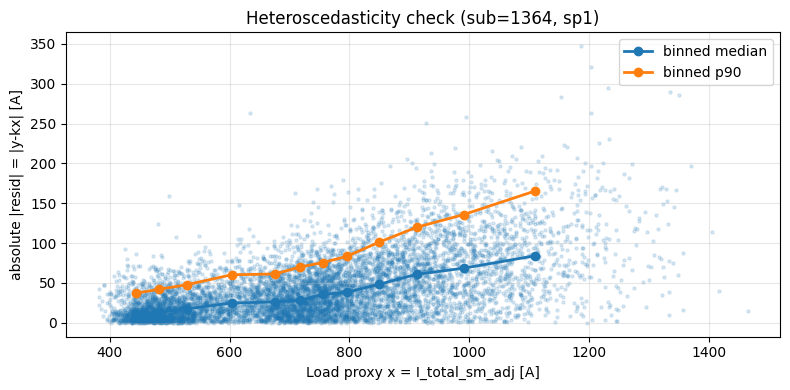

C:\Users\Notandi\AppData\Local\Temp\ipykernel_19952\112839615.py:67: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  b = (g.groupby("_bin")


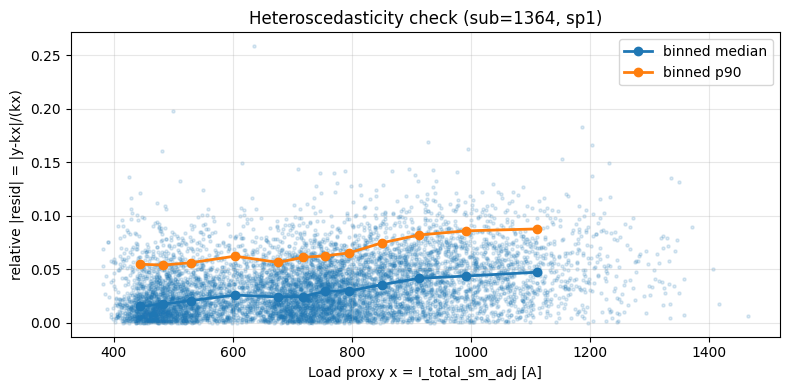

In [11]:
import matplotlib.pyplot as plt

# =========================
# D15+D16 setup: build residual series r(t)
# =========================

# Your policy knobs (already decided)
min_current = 5.0
min_per_completed = 0.88
min_points = 6000

# Your QC thresholds (already decided)
corr_thr = 0.8
r2_thr = 0.8
frac_x_gt_y_thr = 0.05

# ---- valid group list from df_k (quantile WITH intercept) OR df_k0 (no-intercept) ----
# We'll use df_k0 slopes for the residual definition (0->0 scaling model),
# but we can still use df_k QC columns if you prefer.
# If df_k0 doesn't have QC columns, we filter using df_k then merge k_hat0.

df_k["bad_shape"]  = (df_k["corr_xy"] < corr_thr) | (df_k["r2_ols"] < r2_thr)
df_k["bad_physics"] = (df_k["frac_x_gt_y"] > frac_x_gt_y_thr)

valid_groups = df_k.loc[~df_k["bad_shape"] & ~df_k["bad_physics"],
                        ["substation_id", "transformer"]].drop_duplicates()

print("Valid groups:", len(valid_groups), " / total fitted:", df_k[["substation_id","transformer"]].drop_duplicates().shape[0])

# Attach k_hat0 to df_reg (preferred for CT scaling correction)
df_diag = (
    df_reg.merge(valid_groups, on=["substation_id","transformer"], how="inner")
          .merge(df_k0[["substation_id","transformer","k_hat0"]], on=["substation_id","transformer"], how="left")
          .copy()
)
df_diag["k_hat0"] = df_diag["k_hat0"].fillna(1.0)

# Model residuals for diagnostics:
#   y = I_total_jn
#   x = I_total_sm_adj
#   r = y - k*x
df_diag["y"] = df_diag["I_total_jn"].astype(float)
df_diag["x"] = df_diag["I_total_sm_adj"].astype(float)
df_diag["yhat"] = df_diag["k_hat0"] * df_diag["x"]
df_diag["resid"] = df_diag["y"] - df_diag["yhat"]
df_diag["abs_resid"] = df_diag["resid"].abs()
df_diag["rel_abs_resid"] = df_diag["abs_resid"] / df_diag["yhat"].replace(0, np.nan)

print("df_diag shape:", df_diag.shape)
print("Unique valid (sub,trafo):", df_diag.groupby(["substation_id","transformer"]).ngroups)

def plot_heteroscedasticity_group(df_diag, sid, tr, bins=12, use_relative=False, max_points=8000):
    g = df_diag[(df_diag["substation_id"] == sid) & (df_diag["transformer"] == tr)].copy()
    g = g.sort_values("ts")
    if g.empty:
        print("Empty group")
        return

    if len(g) > max_points:
        g = g.iloc[:max_points]

    x = g["x"].to_numpy()
    z = g["rel_abs_resid"].to_numpy() if use_relative else g["abs_resid"].to_numpy()

    # Bin by load quantiles so each bin has ~equal points
    g["_bin"] = pd.qcut(g["x"], q=bins, duplicates="drop")
    b = (g.groupby("_bin")
           .agg(x_med=("x","median"),
                z_med=("rel_abs_resid","median") if use_relative else ("abs_resid","median"),
                z_p90=("rel_abs_resid", lambda s: s.quantile(0.9)) if use_relative else ("abs_resid", lambda s: s.quantile(0.9)),
                n=("x","size"))
           .reset_index(drop=True))

    plt.figure(figsize=(8,4))
    plt.scatter(x, z, s=5, alpha=0.15)
    plt.plot(b["x_med"], b["z_med"], marker="o", linewidth=2, label="binned median")
    plt.plot(b["x_med"], b["z_p90"], marker="o", linewidth=2, label="binned p90")
    plt.xlabel("Load proxy x = I_total_sm_adj [A]")
    plt.ylabel("relative |resid| = |y-kx|/(kx)" if use_relative else "absolute |resid| = |y-kx| [A]")
    plt.title(f"Heteroscedasticity check (sub={sid}, {tr})")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Example (pick one clean group you trust)
plot_heteroscedasticity_group(df_diag, sid=1364, tr="sp1", bins=12, use_relative=False)
plot_heteroscedasticity_group(df_diag, sid=1364, tr="sp1", bins=12, use_relative=True)


C:\Users\Notandi\AppData\Local\Temp\ipykernel_19952\1811375435.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  out = (d.groupby("_bin")


,x_med,rel_med,rel_p90,n
0,79.455000,0.136209,0.316509,6623
1,137.050735,0.063701,0.198711,6623
2,239.110889,0.036795,0.105087,6624
3,348.552632,0.043944,0.126743,6623
4,414.945479,0.055999,0.160685,6623
5,475.020979,0.054641,0.178389,6623
6,530.863636,0.061510,0.198952,6623
7,594.711500,0.065651,0.199862,6623
8,682.960000,0.039083,0.177135,6623
9,755.656015,0.023480,0.159997,6623


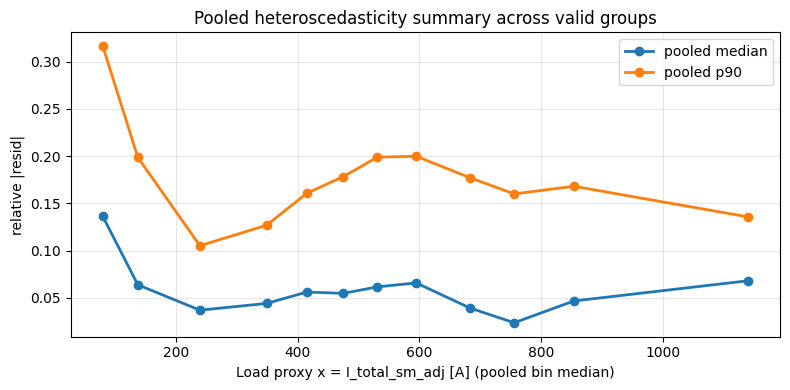

In [12]:
def pooled_hetero_summary(df_diag, bins=12):
    d = df_diag.copy()
    d = d[np.isfinite(d["x"]) & np.isfinite(d["rel_abs_resid"]) & (d["x"] > 0)].copy()

    # pooled bins by x quantiles (across all valid groups)
    d["_bin"] = pd.qcut(d["x"], q=bins, duplicates="drop")
    out = (d.groupby("_bin")
             .agg(x_med=("x","median"),
                  rel_med=("rel_abs_resid","median"),
                  rel_p90=("rel_abs_resid", lambda s: s.quantile(0.9)),
                  n=("x","size"))
             .reset_index(drop=True))
    return out

hetero_pooled = pooled_hetero_summary(df_diag, bins=12)
display(hetero_pooled)

plt.figure(figsize=(8,4))
plt.plot(hetero_pooled["x_med"], hetero_pooled["rel_med"], marker="o", linewidth=2, label="pooled median")
plt.plot(hetero_pooled["x_med"], hetero_pooled["rel_p90"], marker="o", linewidth=2, label="pooled p90")
plt.xlabel("Load proxy x = I_total_sm_adj [A] (pooled bin median)")
plt.ylabel("relative |resid|")
plt.title("Pooled heteroscedasticity summary across valid groups")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [13]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan, het_white

def hetero_tests_for_group(df_diag, sid, tr, max_points=20000):
    g = df_diag[(df_diag["substation_id"] == sid) & (df_diag["transformer"] == tr)].copy()
    g = g[np.isfinite(g["x"]) & np.isfinite(g["y"]) & (g["x"] > 0)].copy()
    g = g.sort_values("ts")
    if len(g) < 500:
        return None

    if len(g) > max_points:
        g = g.iloc[:max_points]

    X = sm.add_constant(g["x"].to_numpy())
    y = g["y"].to_numpy()

    ols = sm.OLS(y, X).fit()
    resid = ols.resid

    bp = het_breuschpagan(resid, X)   # (LM stat, LM p, F stat, F p)
    wh = het_white(resid, X)          # (LM stat, LM p, F stat, F p)

    return {
        "substation_id": sid,
        "transformer": tr,
        "n": len(g),
        "bp_pvalue": bp[1],
        "white_pvalue": wh[1],
        "ols_r2": ols.rsquared,
    }

# Run on a handful of representative valid groups
sample_groups = (
    valid_groups.merge(df_diag.groupby(["substation_id","transformer"]).size().rename("n"), on=["substation_id","transformer"])
               .sort_values("n", ascending=False)
               .head(10)
)

rows = []
for _, r in sample_groups.iterrows():
    res = hetero_tests_for_group(df_diag, int(r["substation_id"]), r["transformer"])
    if res:
        rows.append(res)

hetero_tests = pd.DataFrame(rows).sort_values("bp_pvalue")
display(hetero_tests)


,substation_id,transformer,n,bp_pvalue,white_pvalue,ols_r2
0,1133,sp1,8832,2.555691e-253,5.171270e-278,0.991169
7,246,sp1,8830,9.933091e-248,2.790788e-258,0.961198
1,1364,sp1,8832,1.312644e-145,9.485272e-152,0.987806
3,1248,sp2,8832,4.898387e-143,1.229302e-153,0.962898
5,1456,sp1,8831,1.830449e-139,1.339608e-138,0.809485
2,1029,sp1,8832,2.386964e-96,6.221072e-95,0.888495
6,1482,sp1,8830,2.634034e-91,1.632701e-95,0.967215
8,202,sp2,8826,1.249338e-85,2.295961e-120,0.955944
4,1030,sp1,8832,2.824467e-39,1.943174e-66,0.944041


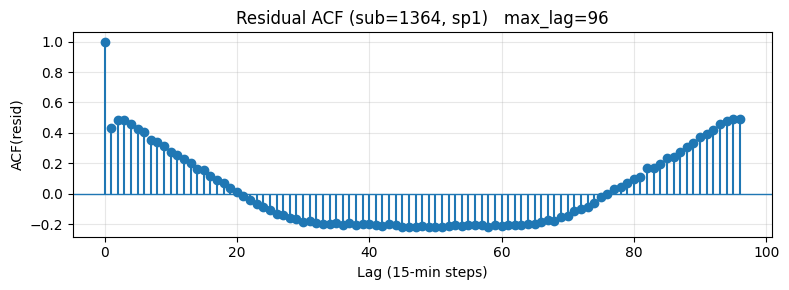

In [14]:
from statsmodels.tsa.stattools import acf

def plot_resid_acf(df_diag, sid, tr, max_lag=96, max_points=20000):
    g = df_diag[(df_diag["substation_id"] == sid) & (df_diag["transformer"] == tr)].copy()
    g = g.sort_values("ts")
    r = g["resid"].to_numpy(dtype=float)
    r = r[np.isfinite(r)]

    if len(r) < max_lag + 10:
        print("Not enough points for ACF")
        return

    if len(r) > max_points:
        r = r[:max_points]

    a = acf(r, nlags=max_lag, fft=True)
    plt.figure(figsize=(8,3))
    plt.stem(range(len(a)), a, basefmt=" ")
    plt.axhline(0, linewidth=1)
    plt.xlabel("Lag (15-min steps)")
    plt.ylabel("ACF(resid)")
    plt.title(f"Residual ACF (sub={sid}, {tr})   max_lag={max_lag}")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# Example
plot_resid_acf(df_diag, sid=1364, tr="sp1", max_lag=96)  # 96 = 24 hours for 15-min data




Valid groups: 9 / 25
Groups after min_points: 9


,k_hat0,k_ols0,k_ols,k_huber0
count,9.000000,9.000000,9.000000,0.0
mean,2.080382,2.216634,2.358080,NaN
std,2.566339,2.709554,3.020871,NaN
min,1.050269,1.133989,1.111659,NaN
25%,1.077171,1.149238,1.210618,NaN
50%,1.214889,1.276455,1.259760,NaN
75%,1.481910,1.618584,1.729916,NaN
max,8.904345,9.422800,10.391210,NaN


,substation_id,transformer,k_hat0,k_ols0,k_ols,b_ols,k_huber0,n_fit
4,1133,sp1,8.904345,9.422800,10.391210,-1082.739321,NaN,8832
6,1364,sp1,1.602277,1.654688,1.729916,-60.620100,NaN,8832
0,202,sp2,1.481910,1.618584,1.736559,-81.989469,NaN,8826
8,1482,sp1,1.224835,1.276455,1.257029,3.971829,NaN,8830
7,1456,sp1,1.214889,1.348284,1.210618,14.282730,NaN,8831
2,1029,sp1,1.104618,1.209722,1.317291,-59.024290,NaN,8832
5,1248,sp2,1.077171,1.149238,1.208676,-26.159908,NaN,8832
3,1030,sp1,1.063128,1.133989,1.111659,16.349134,NaN,8832
1,246,sp1,1.050269,1.135948,1.259760,-71.571947,NaN,8830


Eval rows: 79477
Eval groups: 9


,n_groups,pooled_WAPE,pooled_MAE,median_WAPE,mean_WAPE,median_MAE,mean_MAE
OLS0,9.0,5.326750,28.221302,6.146347,5.879161,33.397578,28.221568
QR0,9.0,7.218473,38.243711,7.933892,8.125684,41.908315,38.244685
OLS,9.0,8.372129,44.355824,8.455675,8.698824,40.682061,44.355593
Before,9.0,201.351048,1066.764635,27.827070,120.196773,90.663210,1066.649151


,,WAPE_Before,WAPE_QR0,WAPE_OLS0,WAPE_OLS,MAE_Before,MAE_QR0,MAE_OLS0,MAE_OLS,dWAPE_QR0,dWAPE_OLS0,dWAPE_OLS
substation_id,transformer,,,,,,,,,,,
1133,sp1,831.055360,5.068800,4.301173,10.449482,8326.570218,50.785686,43.094625,104.696208,825.986561,826.754187,820.605878
1364,sp1,64.896704,3.626423,2.691427,4.927357,485.992823,27.157245,20.155326,36.899564,61.270280,62.205277,59.969347
202,sp2,60.616201,10.056350,6.355387,8.455675,381.134173,63.230925,39.960527,53.166424,50.559851,54.260813,52.160526
1482,sp1,27.827070,5.536951,4.084030,4.308646,52.032076,10.353195,7.636469,8.056465,22.290119,23.743040,23.518424
1456,sp1,36.424377,15.093091,10.367298,15.359763,34.200558,14.171612,9.734342,14.422003,21.331286,26.057080,21.064614
1029,sp1,20.438582,10.542853,7.378662,10.321049,106.356484,54.861966,38.396429,53.707761,9.895729,13.059920,10.117533
1248,sp2,14.403547,7.255634,5.199091,6.836594,58.032707,29.233362,20.947431,27.545026,7.147912,9.204456,7.566953
1030,sp1,13.701220,7.933892,6.146347,6.147961,90.663210,52.499860,40.671382,40.682061,5.767328,7.554873,7.553259
246,sp1,12.407894,8.017161,6.389036,11.482893,64.860110,41.908315,33.397578,60.024828,4.390733,6.018858,0.925001


,WAPE_Before,WAPE_QR0,WAPE_OLS0,WAPE_OLS,MAE_Before,MAE_QR0,MAE_OLS0,MAE_OLS,dWAPE_QR0,dWAPE_OLS0,dWAPE_OLS
count,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000
mean,120.196773,8.125684,5.879161,8.698824,1066.649151,38.244685,28.221568,44.355593,112.071089,114.317611,111.497948
std,267.297002,3.449817,2.216041,3.559268,2727.282149,18.827966,13.819501,28.759645,268.486083,267.934428,266.701913
min,12.407894,3.626423,2.691427,4.308646,34.200558,10.353195,7.636469,8.056465,4.390733,6.018858,0.925001
25%,14.403547,5.536951,4.301173,6.147961,58.032707,27.157245,20.155326,27.545026,7.147912,9.204456,7.566953
50%,27.827070,7.933892,6.146347,8.455675,90.663210,41.908315,33.397578,40.682061,21.331286,23.743040,21.064614
75%,60.616201,10.056350,6.389036,10.449482,381.134173,52.499860,39.960527,53.707761,50.559851,54.260813,52.160526
max,831.055360,15.093091,10.367298,15.359763,8326.570218,63.230925,43.094625,104.696208,825.986561,826.754187,820.605878


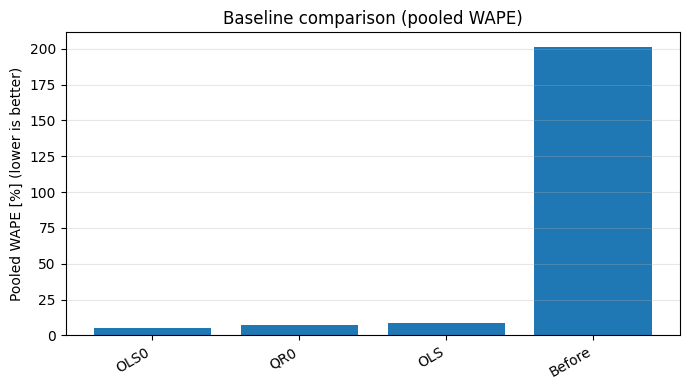

C:\Users\Notandi\AppData\Local\Temp\ipykernel_19952\1845727448.py:219: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=cols, showfliers=False)


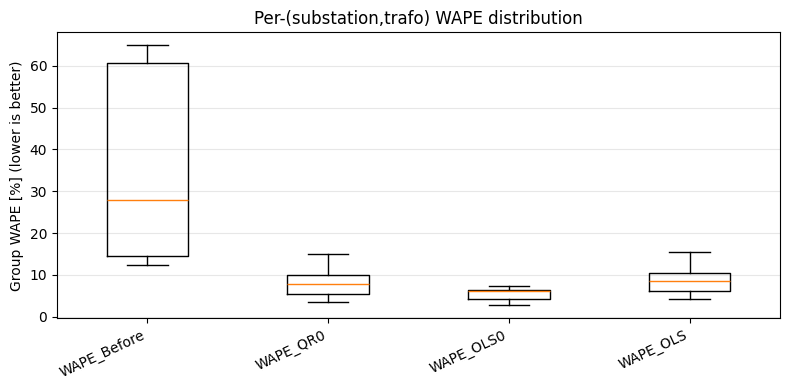

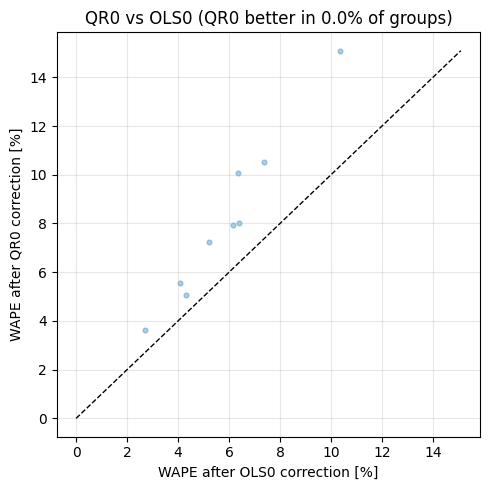

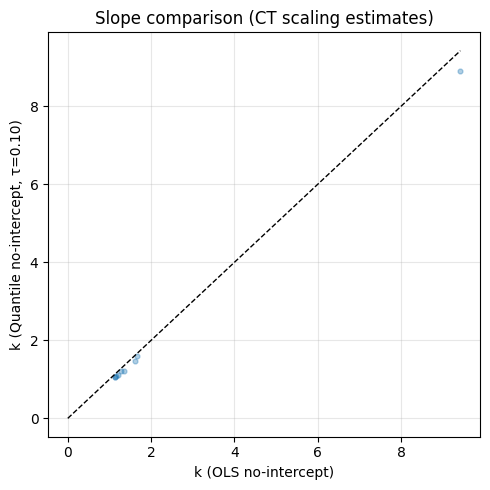

In [15]:
# COMMAND ----------
# D17: Fit baseline slope estimators per (substation_id, transformer)
#################################################################################################################
# We compare k-estimators that you can justify in the thesis:
#  - Quantile regression (tau=0.10) with NO intercept: robust to one-sided positive additive components.
#  - OLS through origin: classic scaling fit assuming zero intercept.
#  - OLS with intercept (slope only used for scaling): shows how additive bias pushes slope upward.
#  - Huber through origin (optional): robust alternative to OLS, less sensitive to outliers.

from sklearn.linear_model import HuberRegressor

xcol = "I_total_sm_adj"   # coverage-adjusted smartmeter current
ycol = "I_total_jn"       # Janitza current

# --- 1) Build the VALID group set (reuse your QC policy) ---
corr_thr = 0.8
r2_thr = 0.8
frac_x_gt_y_thr = 0.05

df_k = df_k.copy()
df_k["bad_shape"]   = (df_k["corr_xy"] < corr_thr) | (df_k["r2_ols"] < r2_thr)
df_k["bad_physics"] = (df_k["frac_x_gt_y"] > frac_x_gt_y_thr)

valid_groups = df_k.loc[~df_k["bad_shape"] & ~df_k["bad_physics"],
                        ["substation_id", "transformer"]].drop_duplicates()

print("Valid groups:", len(valid_groups), "/", df_k[["substation_id","transformer"]].drop_duplicates().shape[0])

# --- 2) Define the FIT dataset (same filters used for k estimation) ---
# IMPORTANT: use the same df_reg you already built with min_current/min_per_completed/min_points policy.
df_fit = (
    df_reg.merge(valid_groups, on=["substation_id","transformer"], how="inner")
          .copy()
)

# Enforce min_points at group level (since df_reg is row-filtered)
gsize = df_fit.groupby(["substation_id","transformer"]).size()
keep_pairs = gsize[gsize >= min_points].index
df_fit = df_fit.set_index(["substation_id","transformer"]).loc[keep_pairs].reset_index()

print("Groups after min_points:", df_fit.groupby(["substation_id","transformer"]).ngroups)

# --- 3) Helper fits ---
def fit_ols_no_intercept(g):
    x = g[xcol].to_numpy(float)
    y = g[ycol].to_numpy(float)
    denom = np.sum(x**2)
    k = np.sum(x*y) / denom if denom > 0 else np.nan
    return k

def fit_ols_with_intercept_slope(g):
    x = g[xcol].to_numpy(float)
    y = g[ycol].to_numpy(float)
    if len(x) < 2:
        return np.nan, np.nan
    k, b = np.polyfit(x, y, 1)  # y ≈ kx + b
    return float(k), float(b)

def fit_huber_no_intercept(g, epsilon=1.35, max_iter=200):
    x = g[xcol].to_numpy(float).reshape(-1, 1)
    y = g[ycol].to_numpy(float)
    try:
        hub = HuberRegressor(fit_intercept=False, epsilon=epsilon, max_iter=max_iter)
        hub.fit(x, y)
        return float(hub.coef_[0])
    except Exception:
        return np.nan

# --- 4) Compute k tables ---
k_rows = []
DO_HUBER = False   # set True if you want; it can be slower

for (sid, tr), g in df_fit.groupby(["substation_id","transformer"]):
    k0_ols = fit_ols_no_intercept(g)
    k_ols, b_ols = fit_ols_with_intercept_slope(g)
    k0_huber = fit_huber_no_intercept(g) if DO_HUBER else np.nan

    k_rows.append({
        "substation_id": sid,
        "transformer": tr,
        "k_ols0": k0_ols,
        "k_ols": k_ols,
        "b_ols": b_ols,
        "k_huber0": k0_huber,
        "n_fit": int(len(g)),
    })

df_k_baselines = pd.DataFrame(k_rows)

# --- 5) Bring in quantile no-intercept slope (your main method) ---
# Make sure df_k0 was computed with your current min_points policy.
# If not, re-run: df_k0 = fit_k_no_intercept(df_reg, tau=0.10, min_points=min_points)

df_k_all = (
    df_k0[["substation_id","transformer","k_hat0"]]
    .merge(df_k_baselines, on=["substation_id","transformer"], how="inner")
)

# Quick sanity summary
display(df_k_all[["k_hat0","k_ols0","k_ols","k_huber0"]].describe())
display(df_k_all.sort_values("k_hat0", ascending=False).head(10))
#################################################################################################################


# COMMAND ----------
# D17: Apply each correction and compare robust metrics using calculate_robust_metrics()
#################################################################################################################
# We evaluate all methods on the SAME evaluation rows (same groups, same bins),
# then compute MAE / RMSE / WAPE / etc using your calculate_robust_metrics().

# --- 1) Build evaluation dataframe ---
# Option: evaluate on df_reg (high-current, high-coverage bins) for apples-to-apples.
# If you want "all bins" later, we can build df_eval from df_merged instead.
df_eval = (
    df_reg.merge(valid_groups, on=["substation_id","transformer"], how="inner")
          .merge(df_k_all, on=["substation_id","transformer"], how="inner")
          .copy()
)

# Guard against bad k values
for c in ["k_hat0","k_ols0","k_ols"]:
    df_eval.loc[~np.isfinite(df_eval[c]) | (df_eval[c] <= 0), c] = np.nan

# Drop rows where any k is missing (keeps evaluation identical across methods)
df_eval = df_eval.dropna(subset=["k_hat0","k_ols0","k_ols"])

print("Eval rows:", len(df_eval))
print("Eval groups:", df_eval.groupby(["substation_id","transformer"]).ngroups)

# --- 2) Correct Janitza using each k (slope-only correction) ---
df_eval["jn_corr_qr0"]   = df_eval[ycol] / df_eval["k_hat0"]   # Quantile no-intercept (main)
df_eval["jn_corr_ols0"]  = df_eval[ycol] / df_eval["k_ols0"]   # OLS no-intercept
df_eval["jn_corr_ols"]   = df_eval[ycol] / df_eval["k_ols"]    # OLS with intercept slope (still slope-only correction)

if DO_HUBER:
    df_eval.loc[~np.isfinite(df_eval["k_huber0"]) | (df_eval["k_huber0"] <= 0), "k_huber0"] = np.nan
    df_eval = df_eval.dropna(subset=["k_huber0"])
    df_eval["jn_corr_huber0"] = df_eval[ycol] / df_eval["k_huber0"]

# --- 3) Compute robust metrics per group ---
# "Before" = compare uncorrected Janitza vs SM_adj
m_before  = calculate_robust_metrics(df_eval, sm_col=xcol, jn_col=ycol)

m_qr0     = calculate_robust_metrics(df_eval, sm_col=xcol, jn_col="jn_corr_qr0")
m_ols0    = calculate_robust_metrics(df_eval, sm_col=xcol, jn_col="jn_corr_ols0")
m_ols     = calculate_robust_metrics(df_eval, sm_col=xcol, jn_col="jn_corr_ols")

metrics_map = {
    "Before": m_before,
    "QR0":    m_qr0,
    "OLS0":   m_ols0,
    "OLS":    m_ols,
}

if DO_HUBER:
    m_huber0 = calculate_robust_metrics(df_eval, sm_col=xcol, jn_col="jn_corr_huber0")
    metrics_map["Huber0"] = m_huber0

# --- 4) Pooled summary (thesis-friendly “one-row per method”) ---
def pooled_summary(stats: pd.DataFrame) -> pd.Series:
    # Use the sums already computed in calculate_robust_metrics
    total_abs = stats["sum_abs_diff"].sum()
    total_sm  = stats["sum_sm_total"].sum()
    total_n   = stats["n_points"].sum()

    out = {
        "n_groups": int(len(stats)),
        "pooled_WAPE": 100 * total_abs / total_sm if total_sm > 0 else np.nan,
        "pooled_MAE":  total_abs / total_n if total_n > 0 else np.nan,
        "median_WAPE": float(stats["WAPE"].median()),
        "mean_WAPE":   float(stats["WAPE"].mean()),
        "median_MAE":  float(stats["MAE"].median()),
        "mean_MAE":    float(stats["MAE"].mean()),
    }
    return pd.Series(out)

summary_table = pd.DataFrame({name: pooled_summary(st) for name, st in metrics_map.items()}).T
display(summary_table.sort_values("pooled_WAPE"))

# --- 5) Per-group comparison table (for plots/rankings) ---
# (Lower is better for all errors)
cmp = pd.DataFrame(index=m_before.index)
cmp["WAPE_Before"] = m_before["WAPE"]
cmp["WAPE_QR0"]    = m_qr0["WAPE"]
cmp["WAPE_OLS0"]   = m_ols0["WAPE"]
cmp["WAPE_OLS"]    = m_ols["WAPE"]

cmp["MAE_Before"]  = m_before["MAE"]
cmp["MAE_QR0"]     = m_qr0["MAE"]
cmp["MAE_OLS0"]    = m_ols0["MAE"]
cmp["MAE_OLS"]     = m_ols["MAE"]

# Improvement columns (positive = improved)
cmp["dWAPE_QR0"]   = cmp["WAPE_Before"] - cmp["WAPE_QR0"]
cmp["dWAPE_OLS0"]  = cmp["WAPE_Before"] - cmp["WAPE_OLS0"]
cmp["dWAPE_OLS"]   = cmp["WAPE_Before"] - cmp["WAPE_OLS"]

display(cmp.sort_values("dWAPE_QR0", ascending=False).head(20))
display(cmp.describe())

#################################################################################################################
# COMMAND ----------
# Quick glance plots for D17 (baselines vs quantile)

# ---------- 1) Pooled performance bar chart (lower is better) ----------
st = summary_table.copy()
st = st.sort_values("pooled_WAPE")  # best on top
plt.figure(figsize=(7,4))
plt.bar(st.index.astype(str), st["pooled_WAPE"].to_numpy())
plt.ylabel("Pooled WAPE [%] (lower is better)")
plt.title("Baseline comparison (pooled WAPE)")
plt.grid(alpha=0.3, axis="y")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# ---------- 2) Per-group WAPE distribution (boxplot) ----------
cols = ["WAPE_Before", "WAPE_QR0", "WAPE_OLS0", "WAPE_OLS"]
data = [cmp[c].replace([np.inf, -np.inf], np.nan).dropna().to_numpy() for c in cols]

plt.figure(figsize=(8,4))
plt.boxplot(data, labels=cols, showfliers=False)
plt.ylabel("Group WAPE [%] (lower is better)")
plt.title("Per-(substation,trafo) WAPE distribution")
plt.grid(alpha=0.3, axis="y")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

# ---------- 3) Head-to-head: QR0 vs OLS0 (each dot = one group) ----------
x = cmp["WAPE_OLS0"].to_numpy(float)
y = cmp["WAPE_QR0"].to_numpy(float)
m = np.isfinite(x) & np.isfinite(y)
x = x[m]; y = y[m]

better = np.mean(y < x)  # fraction where QR0 beats OLS0
mx = np.nanmax([np.nanmax(x), np.nanmax(y)])

plt.figure(figsize=(5,5))
plt.scatter(x, y, s=12, alpha=0.35)
plt.plot([0, mx], [0, mx], "k--", lw=1)
plt.xlabel("WAPE after OLS0 correction [%]")
plt.ylabel("WAPE after QR0 correction [%]")
plt.title(f"QR0 vs OLS0 (QR0 better in {better*100:.1f}% of groups)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ---------- 4) k comparison: QR0 slope vs OLS0 slope ----------
# (shows systematic bias of OLS when there is additive unmetered/NTL)
kx = df_k_all["k_ols0"].to_numpy(float)
ky = df_k_all["k_hat0"].to_numpy(float)
m = np.isfinite(kx) & np.isfinite(ky) & (kx > 0) & (ky > 0)
kx = kx[m]; ky = ky[m]
mx = np.nanmax([np.nanmax(kx), np.nanmax(ky)])

plt.figure(figsize=(5,5))
plt.scatter(kx, ky, s=12, alpha=0.35)
plt.plot([0, mx], [0, mx], "k--", lw=1)
plt.xlabel("k (OLS no-intercept)")
plt.ylabel("k (Quantile no-intercept, τ=0.10)")
plt.title("Slope comparison (CT scaling estimates)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Matched 25 groups.


,substation_id,transformer,k_hat0,alpha_ct,per_completed,k_diff,k_ratio
0,202,sp2,1.481910,1.572466,0.880000,-0.090556,0.942412
1,246,sp1,1.050269,1.130348,0.886667,-0.080079,0.929155
2,411,sp1,0.935069,0.864957,1.000000,0.070112,1.081059
3,537,sp1,0.536463,0.548163,0.938619,-0.011700,0.978657
4,579,sp1,0.801936,0.855800,0.886792,-0.053864,0.937060


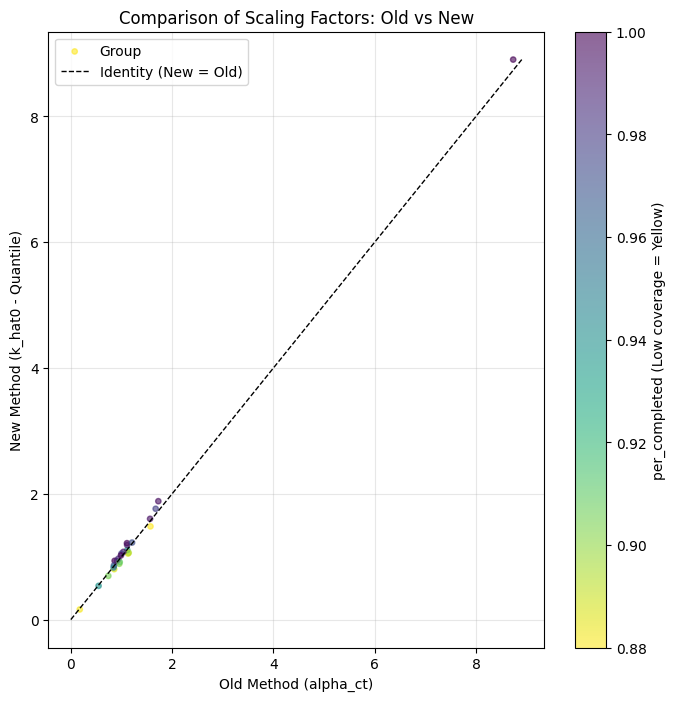

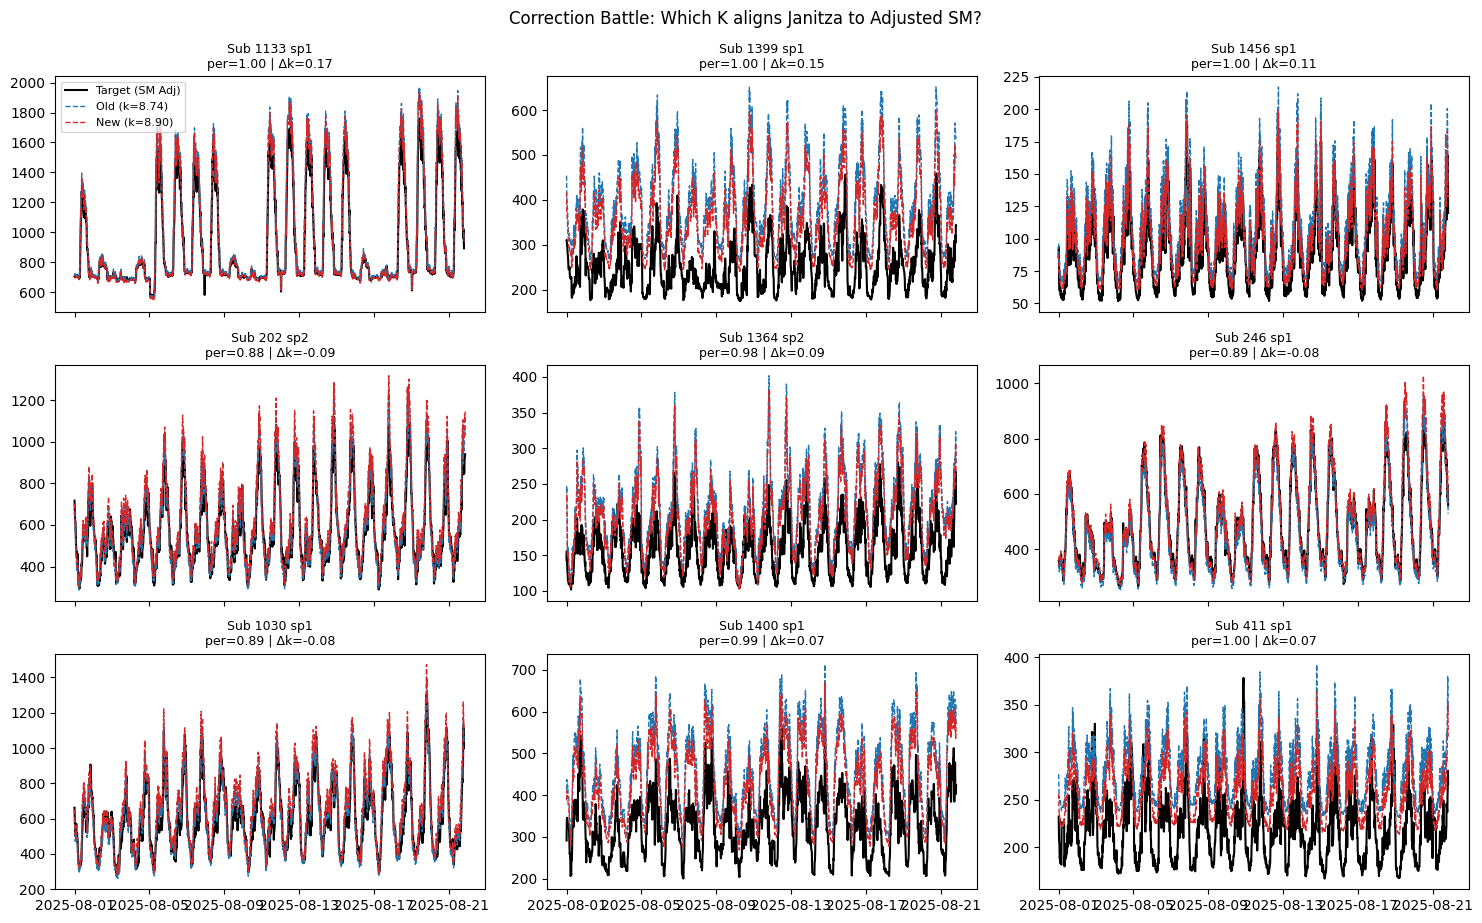

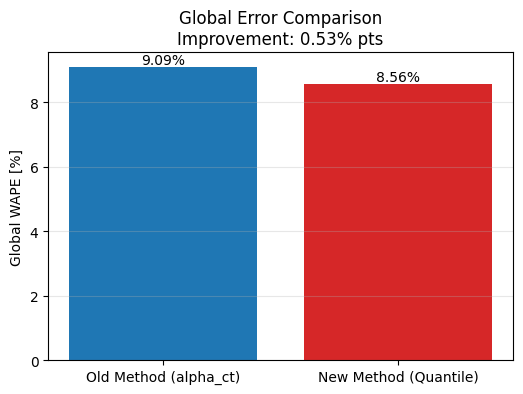

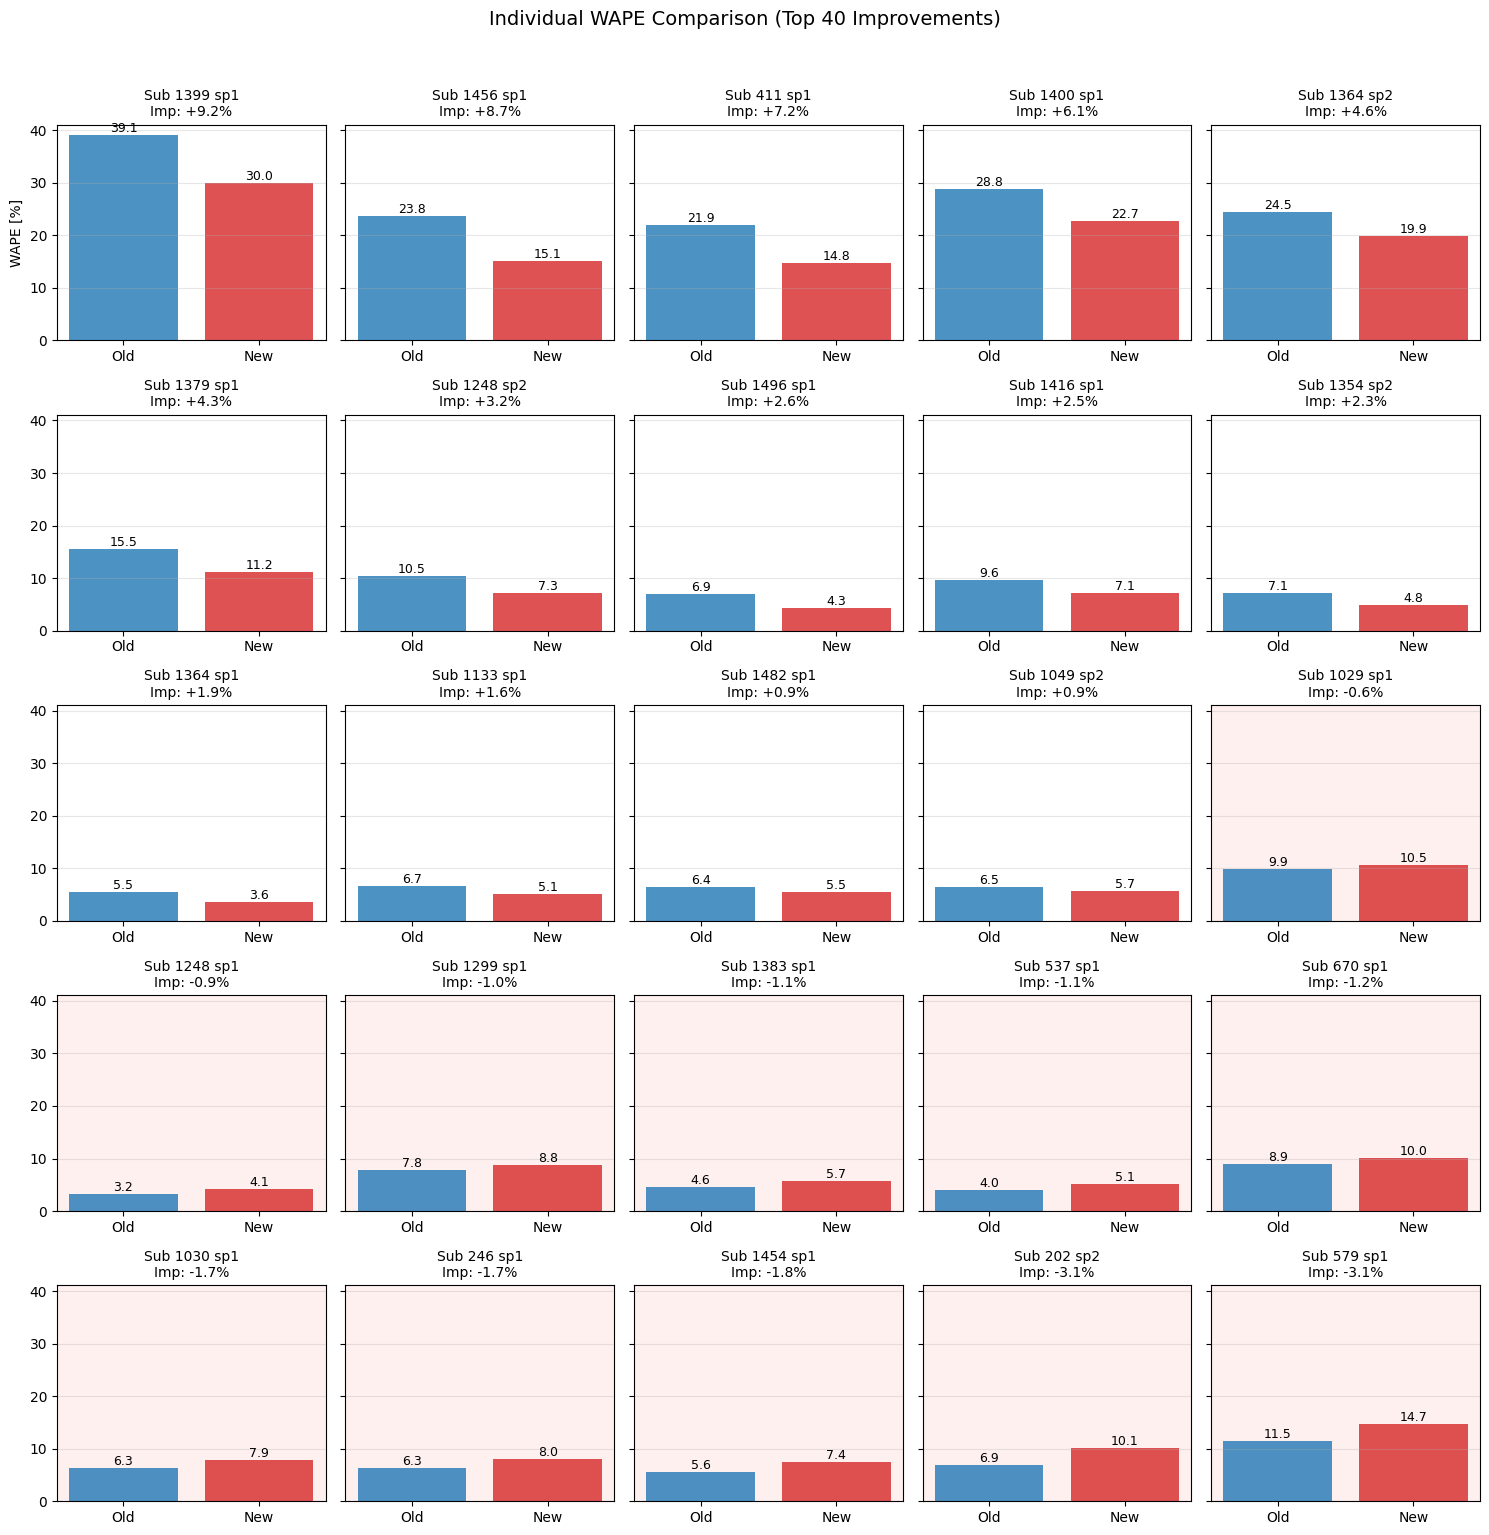

In [24]:
import matplotlib.pyplot as plt
import math
import numpy as np
# =========================================================
# 0. CRITICAL FIX: Ensure df_merged has the adjusted target column
# =========================================================
# Ensure per_completed is numeric and handled correctly (0-1 vs 0-100)
df_merged["per_completed"] = pd.to_numeric(df_merged["per_completed"], errors="coerce")
mask_pct = df_merged["per_completed"] > 1.5
df_merged.loc[mask_pct, "per_completed"] = df_merged.loc[mask_pct, "per_completed"] / 100.0

# Calculate the adjusted target (Smart Meter / Coverage) if it doesn't exist or needs refresh
df_merged["I_total_sm_adj"] = df_merged["I_total_sm"] / df_merged["per_completed"]


# =========================================================
# 1. Merge New (k_hat0) and Old (alpha_ct)
# =========================================================
df_compare_k = df_k0[["substation_id", "transformer", "k_hat0"]].merge(
    df_computed[["substation_id", "transformer", "alpha_ct", "per_completed"]],
    on=["substation_id", "transformer"],
    how="inner"
)

# Calculate the difference and ratio
df_compare_k["k_diff"] = df_compare_k["k_hat0"] - df_compare_k["alpha_ct"]
df_compare_k["k_ratio"] = df_compare_k["k_hat0"] / df_compare_k["alpha_ct"]

print(f"Matched {len(df_compare_k)} groups.")
display(df_compare_k.head())

# =========================================================
# 2. Scatter Plot: Old vs New K
# =========================================================
import matplotlib.pyplot as plt
import numpy as np

def plot_k_comparison_scatter(df_cmp):
    plt.figure(figsize=(8, 8))
    
    # Color by per_completed to see if low coverage explains the difference
    sc = plt.scatter(
        df_cmp["alpha_ct"], 
        df_cmp["k_hat0"], 
        c=df_cmp["per_completed"], 
        cmap="viridis_r", 
        s=15, 
        alpha=0.6,
        label="Group"
    )
    
    # 1:1 Line
    mx = max(df_cmp["alpha_ct"].max(), df_cmp["k_hat0"].max())
    plt.plot([0, mx], [0, mx], "k--", lw=1, label="Identity (New = Old)")
    
    plt.colorbar(sc, label="per_completed (Low coverage = Yellow)")
    plt.xlabel("Old Method (alpha_ct)")
    plt.ylabel("New Method (k_hat0 - Quantile)")
    plt.title("Comparison of Scaling Factors: Old vs New")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

plot_k_comparison_scatter(df_compare_k)

# =========================================================
# 3. Time Series Grid: Visual Proof
# =========================================================
def plot_correction_battle_grid(
    merged_df, 
    k_df, 
    substation_transformers=None, 
    max_plots=12, 
    cols=3,
    max_points=2000
):
    """
    Plots:
      1. Black Line: Target (Smart Meter Adjusted)
      2. Blue Dashed: Old Correction (Janitza / alpha_ct)
      3. Red Dashed: New Correction (Janitza / k_hat0)
    """
    
    # Merge coefficients into the time series data
    df = merged_df.merge(
        k_df, 
        on=["substation_id", "transformer"], 
        how="inner",
        suffixes=('', '_k')
    )
    
    # Filter candidates (e.g., biggest disagreement between k's)
    if substation_transformers is None:
        # Sort by biggest absolute difference in K
        candidates = df[["substation_id", "transformer", "k_diff"]].drop_duplicates()
        candidates["abs_diff"] = candidates["k_diff"].abs()
        candidates = candidates.sort_values("abs_diff", ascending=False).head(max_plots)
        pairs = list(zip(candidates["substation_id"], candidates["transformer"]))
    else:
        pairs = substation_transformers[:max_plots]

    rows = math.ceil(len(pairs) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 3 * rows), sharex=True)
    axes = np.array(axes).reshape(-1)

    for ax, (sid, tr) in zip(axes, pairs):
        g = df[(df["substation_id"] == sid) & (df["transformer"] == tr)].sort_values("ts")
        if len(g) > max_points: 
            g = g.iloc[:max_points]

        # Get coefficients
        k_new = g["k_hat0"].iloc[0]
        k_old = g["alpha_ct"].iloc[0]
        per = g["per_completed"].iloc[0]

        # 1. Target (The Truth we want to hit)
        ax.plot(g["ts"], g["I_total_sm_adj"], color="black", lw=1.5, label="Target (SM Adj)", zorder=1)

        # 2. Old Correction
        if k_old > 0:
            ax.plot(g["ts"], g["I_total_jn"] / k_old, color="tab:blue", ls="--", lw=1, label=f"Old (k={k_old:.2f})")

        # 3. New Correction
        if k_new > 0:
            ax.plot(g["ts"], g["I_total_jn"] / k_new, color="tab:red", ls="--", lw=1, label=f"New (k={k_new:.2f})")

        ax.set_title(f"Sub {sid} {tr}\nper={per:.2f} | Δk={k_new - k_old:.2f}", fontsize=9)
        
        # Only legend on first plot to save space
        if ax == axes[0]:
            ax.legend(fontsize=8)

    # Hide unused
    for ax in axes[len(pairs):]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.suptitle("Correction Battle: Which K aligns Janitza to Adjusted SM?", y=1.02)
    plt.show()

# Run the plot
plot_correction_battle_grid(df_merged, df_compare_k, max_plots=9, cols=3)

# =========================================================
# 4. Global Metric Comparison (WAPE)
# =========================================================

# Avoid column collision: Drop per_completed from df_compare_k before merging
# because df_merged already has it.
cols_to_merge = [c for c in df_compare_k.columns if c != "per_completed"]

df_eval_final = df_merged.merge(
    df_compare_k[cols_to_merge], 
    on=["substation_id", "transformer"], 
    how="inner"
)

# Correct Janitza using OLD method
df_eval_final["jn_corr_OLD"] = df_eval_final["I_total_jn"] / df_eval_final["alpha_ct"]
# Correct Janitza using NEW method
df_eval_final["jn_corr_NEW"] = df_eval_final["I_total_jn"] / df_eval_final["k_hat0"]

# Calculate metrics against the "Truth" (I_total_sm_adj)
metrics_old = calculate_robust_metrics(df_eval_final, sm_col="I_total_sm_adj", jn_col="jn_corr_OLD")
metrics_new = calculate_robust_metrics(df_eval_final, sm_col="I_total_sm_adj", jn_col="jn_corr_NEW")

# Aggregate WAPE
wape_old = (metrics_old["sum_abs_diff"].sum() / metrics_old["sum_sm_total"].sum()) * 100
wape_new = (metrics_new["sum_abs_diff"].sum() / metrics_new["sum_sm_total"].sum()) * 100

# Plot
plt.figure(figsize=(6, 4))
bars = plt.bar(["Old Method (alpha_ct)", "New Method (Quantile)"], [wape_old, wape_new], color=["tab:blue", "tab:red"])
plt.ylabel("Global WAPE [%]")
plt.title(f"Global Error Comparison\nImprovement: {wape_old - wape_new:.2f}% pts")
plt.bar_label(bars, fmt='%.2f%%')
plt.grid(axis='y', alpha=0.3)
plt.show()
def plot_individual_wape_comparison(
    metrics_old, 
    metrics_new, 
    max_plots=20, 
    cols=4
):
    """
    Plots a grid of bar charts. Each subplot represents ONE (substation, transformer).
    Left Bar (Blue): WAPE using Old Method
    Right Bar (Red): WAPE using New Method
    """
    
    # 1. Merge metrics to compare side-by-side
    # metrics_old and metrics_new are indexed by (substation_id, transformer)
    comparison = metrics_old[["WAPE"]].rename(columns={"WAPE": "WAPE_Old"}).join(
        metrics_new[["WAPE"]].rename(columns={"WAPE": "WAPE_New"}),
        how="inner"
    )
    
    # 2. Calculate Improvement (Positive means New is better)
    comparison["Improvement"] = comparison["WAPE_Old"] - comparison["WAPE_New"]
    
    # 3. Sort by "Biggest Improvement" first
    comparison = comparison.sort_values("Improvement", ascending=False).head(max_plots)
    
    # 4. Setup Grid
    n_plots = len(comparison)
    rows = math.ceil(n_plots / cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows), sharey=True)
    axes = np.array(axes).reshape(-1)
    
    # 5. Plot each transformer
    for ax, ((sid, tr), row) in zip(axes, comparison.iterrows()):
        
        # Data for this specific transformer
        values = [row["WAPE_Old"], row["WAPE_New"]]
        labels = ["Old", "New"]
        colors = ["tab:blue", "tab:red"]
        
        # Bar Plot
        bars = ax.bar(labels, values, color=colors, alpha=0.8)
        
        # Labels and Titles
        ax.set_title(f"Sub {sid} {tr}\nImp: {row['Improvement']:+.1f}%", fontsize=10)
        ax.grid(axis='y', alpha=0.3)
        
        # Add value numbers on top of bars
        ax.bar_label(bars, fmt='%.1f', fontsize=9)
        
        # Highlight background if "New" is worse (negative improvement)
        if row["Improvement"] < 0:
            ax.set_facecolor('#fff0f0') # Light red background for regressions

    # Hide unused axes
    for ax in axes[n_plots:]:
        ax.set_visible(False)
        
    # Global Label
    axes[0].set_ylabel("WAPE [%]")
    plt.suptitle(f"Individual WAPE Comparison (Top {max_plots} Improvements)", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

# Run the plotter
# It uses the metrics_old / metrics_new dataframes you created in the previous step
plot_individual_wape_comparison(metrics_old, metrics_new, max_plots=40, cols=5)

Starting sweep for taus: [0.01, 0.02, 0.05, 0.08, 0.1, 0.12, 0.15, 0.2, 0.25, 0.5, 0.75, 0.9, 0.99]
tau=0.01  | Median k=0.964 | Global WAPE=16.25%
tau=0.02  | Median k=0.974 | Global WAPE=14.67%
tau=0.05  | Median k=0.991 | Global WAPE=12.46%
tau=0.08  | Median k=1.000 | Global WAPE=11.22%
tau=0.1   | Median k=1.011 | Global WAPE=10.62%
tau=0.12  | Median k=1.021 | Global WAPE=10.11%
tau=0.15  | Median k=1.033 | Global WAPE=9.45%
tau=0.2   | Median k=1.050 | Global WAPE=8.56%
tau=0.25  | Median k=1.060 | Global WAPE=7.79%
tau=0.5   | Median k=1.104 | Global WAPE=5.97%
tau=0.75  | Median k=1.177 | Global WAPE=7.02%
tau=0.9   | Median k=1.243 | Global WAPE=9.94%
tau=0.99  | Median k=1.332 | Global WAPE=16.15%


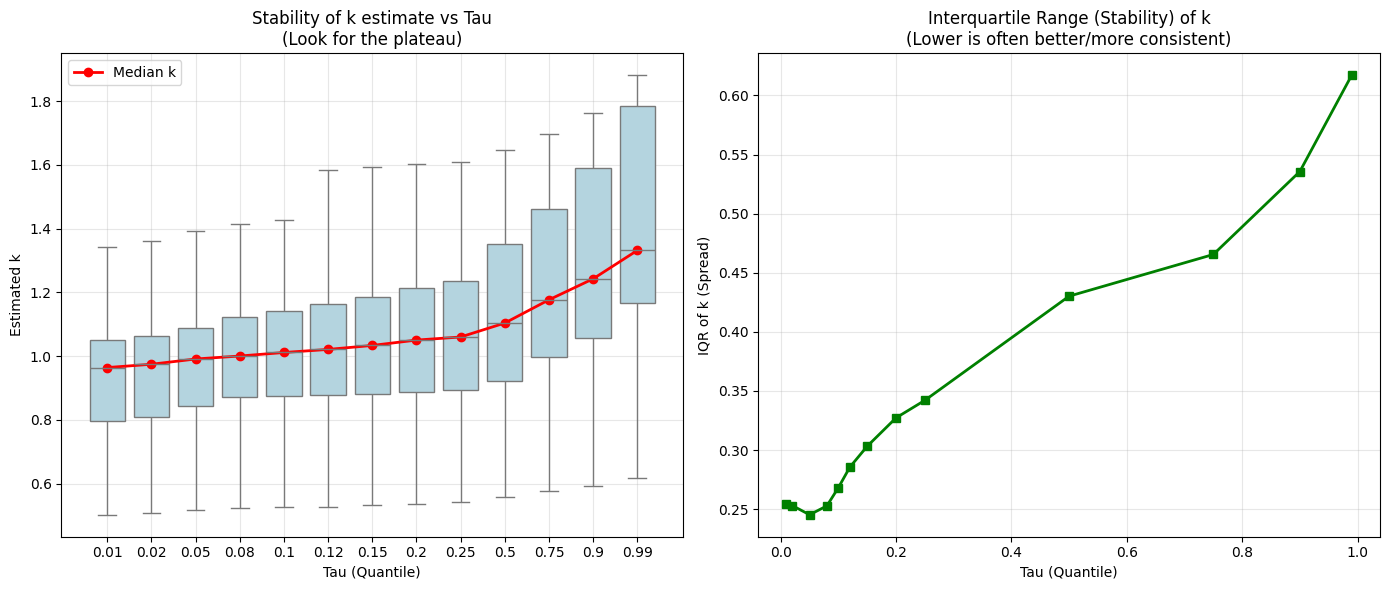

In [18]:
# =========================================================
# Tau Sensitivity Analysis
# =========================================================

def analyze_tau_sensitivity(
    df_reg, 
    taus=[0.01, 0.025, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.50],
    min_points=2000
):
    """
    Fits k for multiple values of tau to find the stable region.
    Returns:
      1. df_results: Long-format dataframe of k values for every group and tau.
      2. summary: Aggregated performance metrics per tau.
    """
    results = []
    
    print(f"Starting sweep for taus: {taus}")
    
    for t in taus:
        # Fit k using your existing no-intercept function
        df_k = fit_k_no_intercept(df_reg, tau=t, min_points=min_points)
        
        # Merge back to calculate metrics
        # We use a temporary eval frame to check error
        df_eval = df_reg.merge(df_k, on=["substation_id", "transformer"], how="inner")
        
        # Correct Janitza
        df_eval["jn_corr"] = df_eval["I_total_jn"] / df_eval["k_hat0"]
        
        # Calculate Global WAPE for this tau
        sum_abs_diff = (df_eval["jn_corr"] - df_eval["I_total_sm_adj"]).abs().sum()
        sum_sm = df_eval["I_total_sm_adj"].sum()
        wape = 100 * sum_abs_diff / sum_sm if sum_sm > 0 else np.nan
        
        # Calculate Median k (to see the drift)
        median_k = df_k["k_hat0"].median()
        
        # Store group-level results
        df_k["tau"] = t
        results.append(df_k)
        
        print(f"tau={t:<5} | Median k={median_k:.3f} | Global WAPE={wape:.2f}%")

    # Combine all results
    df_results = pd.concat(results, ignore_index=True)
    
    return df_results

# Run the analysis
# Use the df_reg you created earlier (the filtered dataset)
taus_to_test = [0.01, 0.02, 0.05, 0.08, 0.10, 0.12, 0.15, 0.20, 0.25, 0.50, 0.75, 0.90, 0.99]
df_tau_results = analyze_tau_sensitivity(df_reg, taus=taus_to_test, min_points=min_points)
import seaborn as sns

def plot_tau_diagnostics(df_res):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # --- Plot 1: Boxplot of k estimates vs Tau ---
    # This shows STABILITY. You want to pick a tau in the "flat" region.
    sns.boxplot(data=df_res, x="tau", y="k_hat0", ax=ax1, color="lightblue", showfliers=False)
    
    # Connect the medians with a line to visualize the drift
    medians = df_res.groupby("tau")["k_hat0"].median()
    ax1.plot(range(len(medians)), medians.values, marker='o', color='red', lw=2, label="Median k")
    
    ax1.set_title("Stability of k estimate vs Tau\n(Look for the plateau)")
    ax1.set_ylabel("Estimated k")
    ax1.set_xlabel("Tau (Quantile)")
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    # --- Plot 2: Variance/Spread of k ---
    # We want a tau that produces TIGHT clusters of k (low variance across similar transformers)
    # If tau is too low, k is erratic (high spread).
    iqr = df_res.groupby("tau")["k_hat0"].agg(lambda x: x.quantile(0.75) - x.quantile(0.25))
    
    ax2.plot(iqr.index, iqr.values, marker='s', color='green', lw=2)
    ax2.set_title("Interquartile Range (Stability) of k\n(Lower is often better/more consistent)")
    ax2.set_ylabel("IQR of k (Spread)")
    ax2.set_xlabel("Tau (Quantile)")
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_tau_diagnostics(df_tau_results)

If the issue is CT scaling then we expect the dots to be spread around the corrected line

In [23]:
# This code block is for computing diagnostics and plotting and showing that the CT scaling is issue that is causing the diffences between the two datasets.
#################################################################################################################
df_computed = compute_ct_diagnostics(df_merged)
substation_id = 1398
transformer = "sp1"  # or "sp2"

# alpha = df_computed.loc[
#     (df_computed["substation_id"] == substation_id) &
#     (df_computed["transformer"] == transformer),
#     "alpha_ls"
# ].values[0]

# plot_substation_scatter(
#     merged=df_merged,
#     sid=substation_id,
#     transformer=transformer,
#     alpha=alpha,
# )
#################################################################################################################


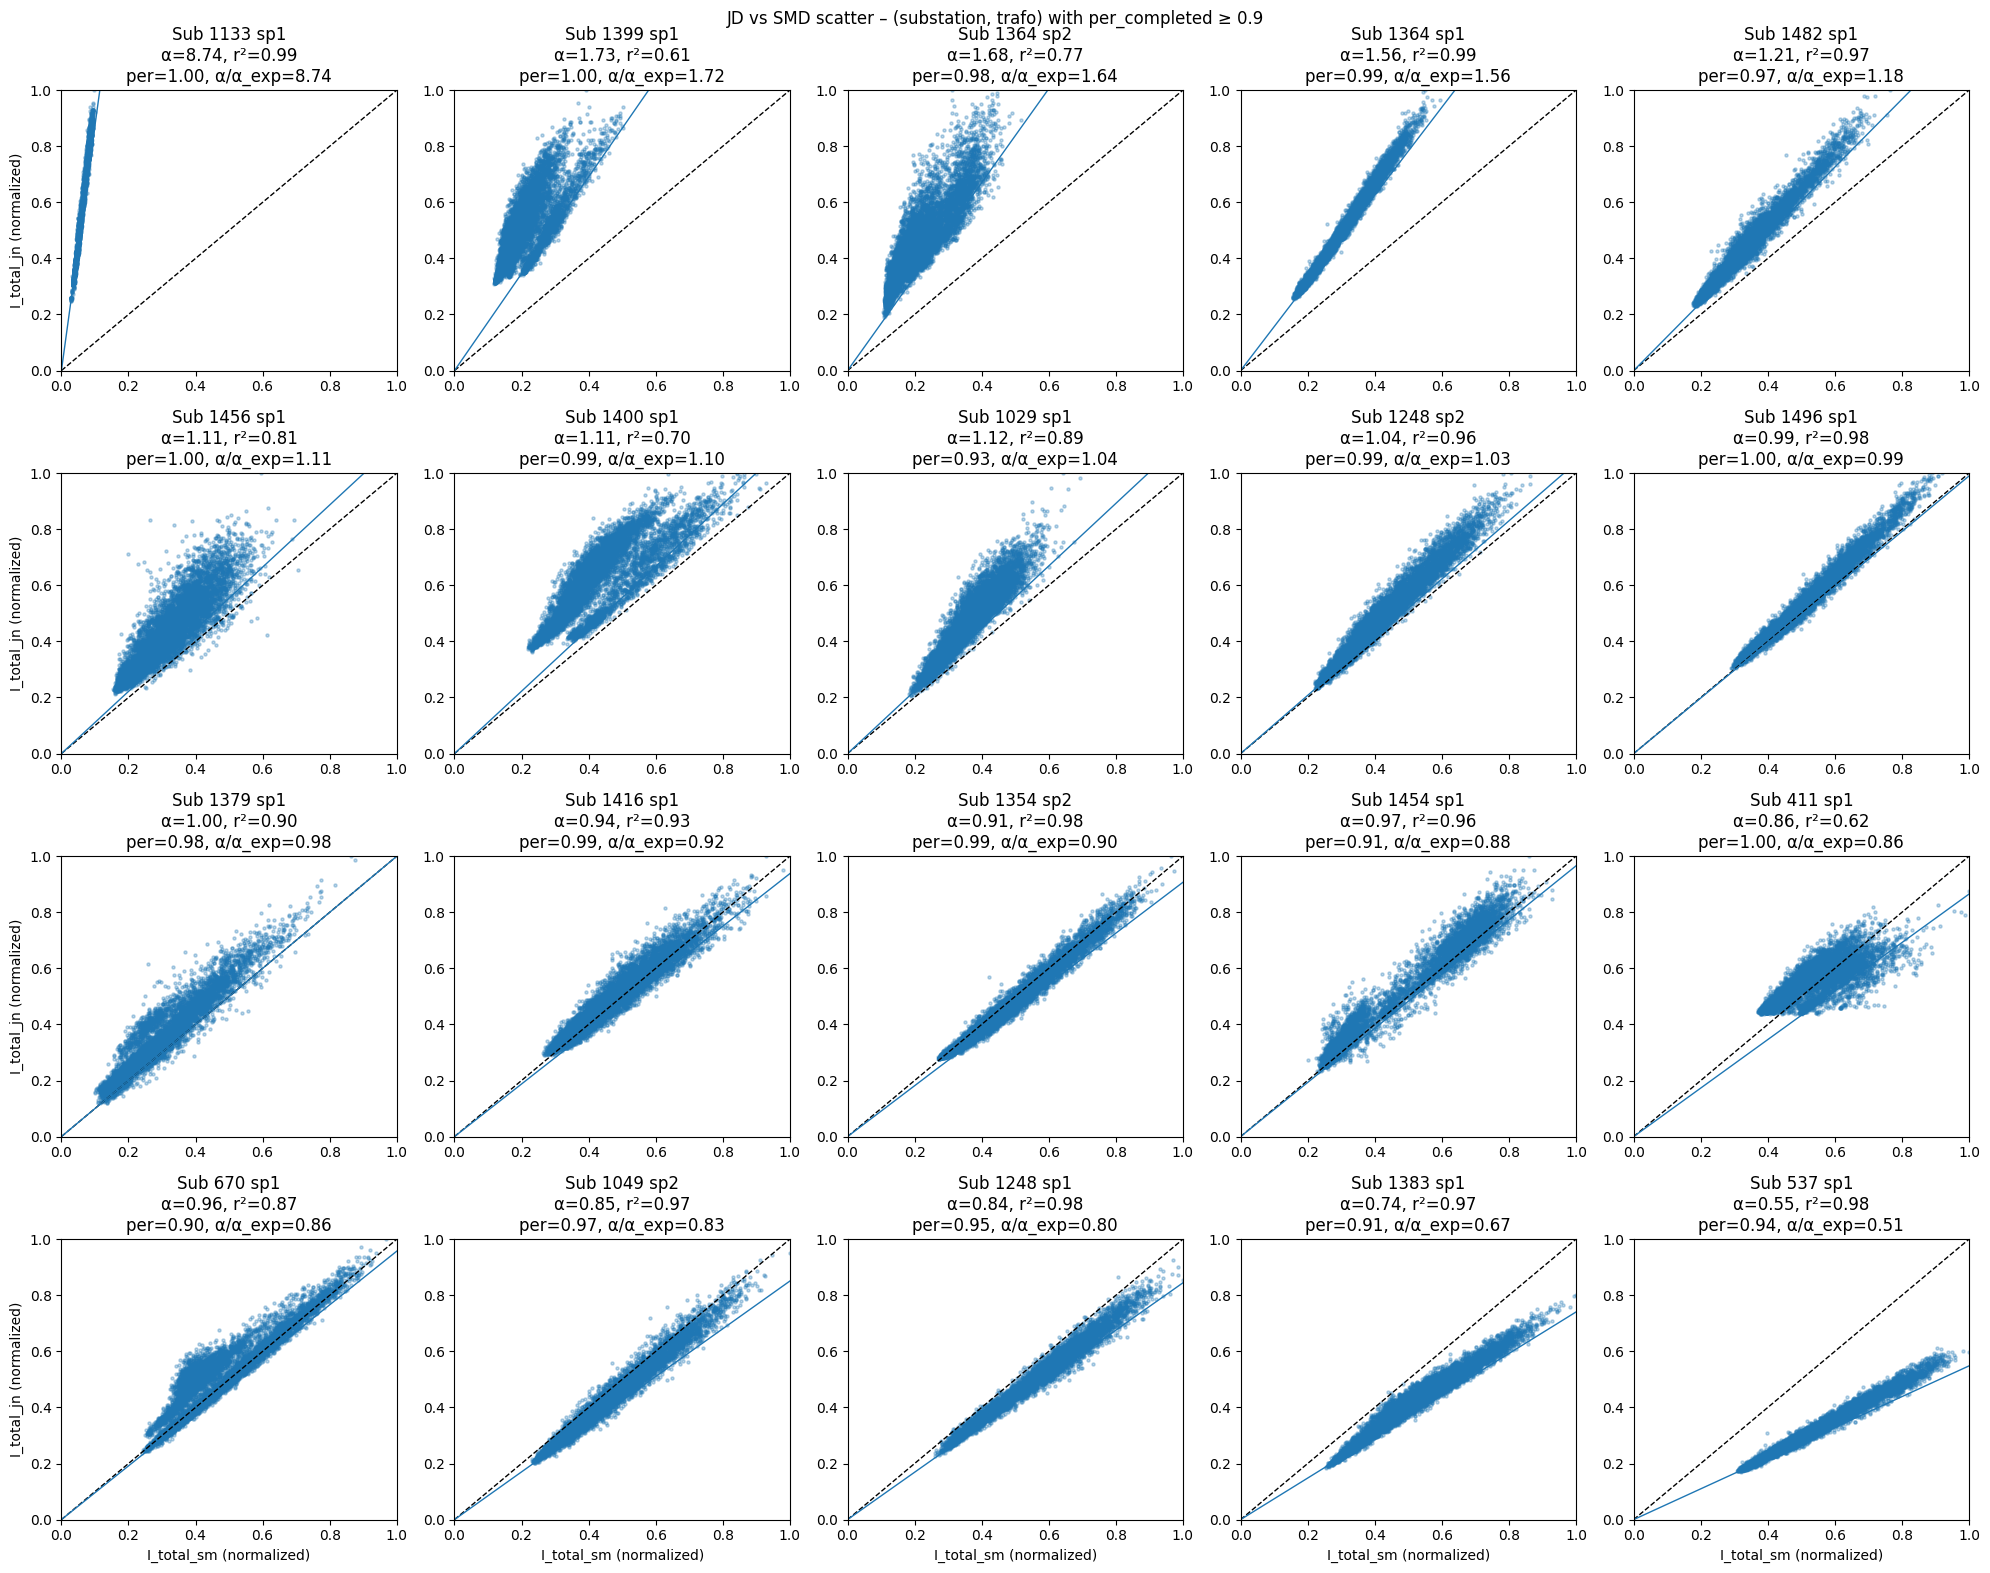

In [25]:
# This code block is for plotting a grid of time series for multiple substations and transformers.
#################################################################################################################
plot_scatter_grid(
    merged=df_merged,
    summary=df_computed,
    min_per_completed=0.9,
    max_plots=42,
    cols=5,
)
#################################################################################################################


                           MAE_Before   MAE_After  WAPE_Before  WAPE_After  \
substation_id transformer                                                    
1399          sp1          426.431554  120.144050   140.672385   39.633442   
1400          sp1          164.874457  112.102614    44.286793   30.111791   
1364          sp2          225.215662   54.305163   111.622037   26.914882   
1456          sp1           34.200558   22.313931    36.424377   23.764848   
411           sp1           24.766009   51.662528    10.514964   21.934483   

                           RMSE_Before  RMSE_After  n_mps  
substation_id transformer                                  
1399          sp1           442.820339  136.172447    165  
1400          sp1           177.410649  126.309564    136  
1364          sp2           238.082158   65.324182    105  
1456          sp1            38.990017   27.058919     63  
411           sp1            28.218650   56.048763    127  


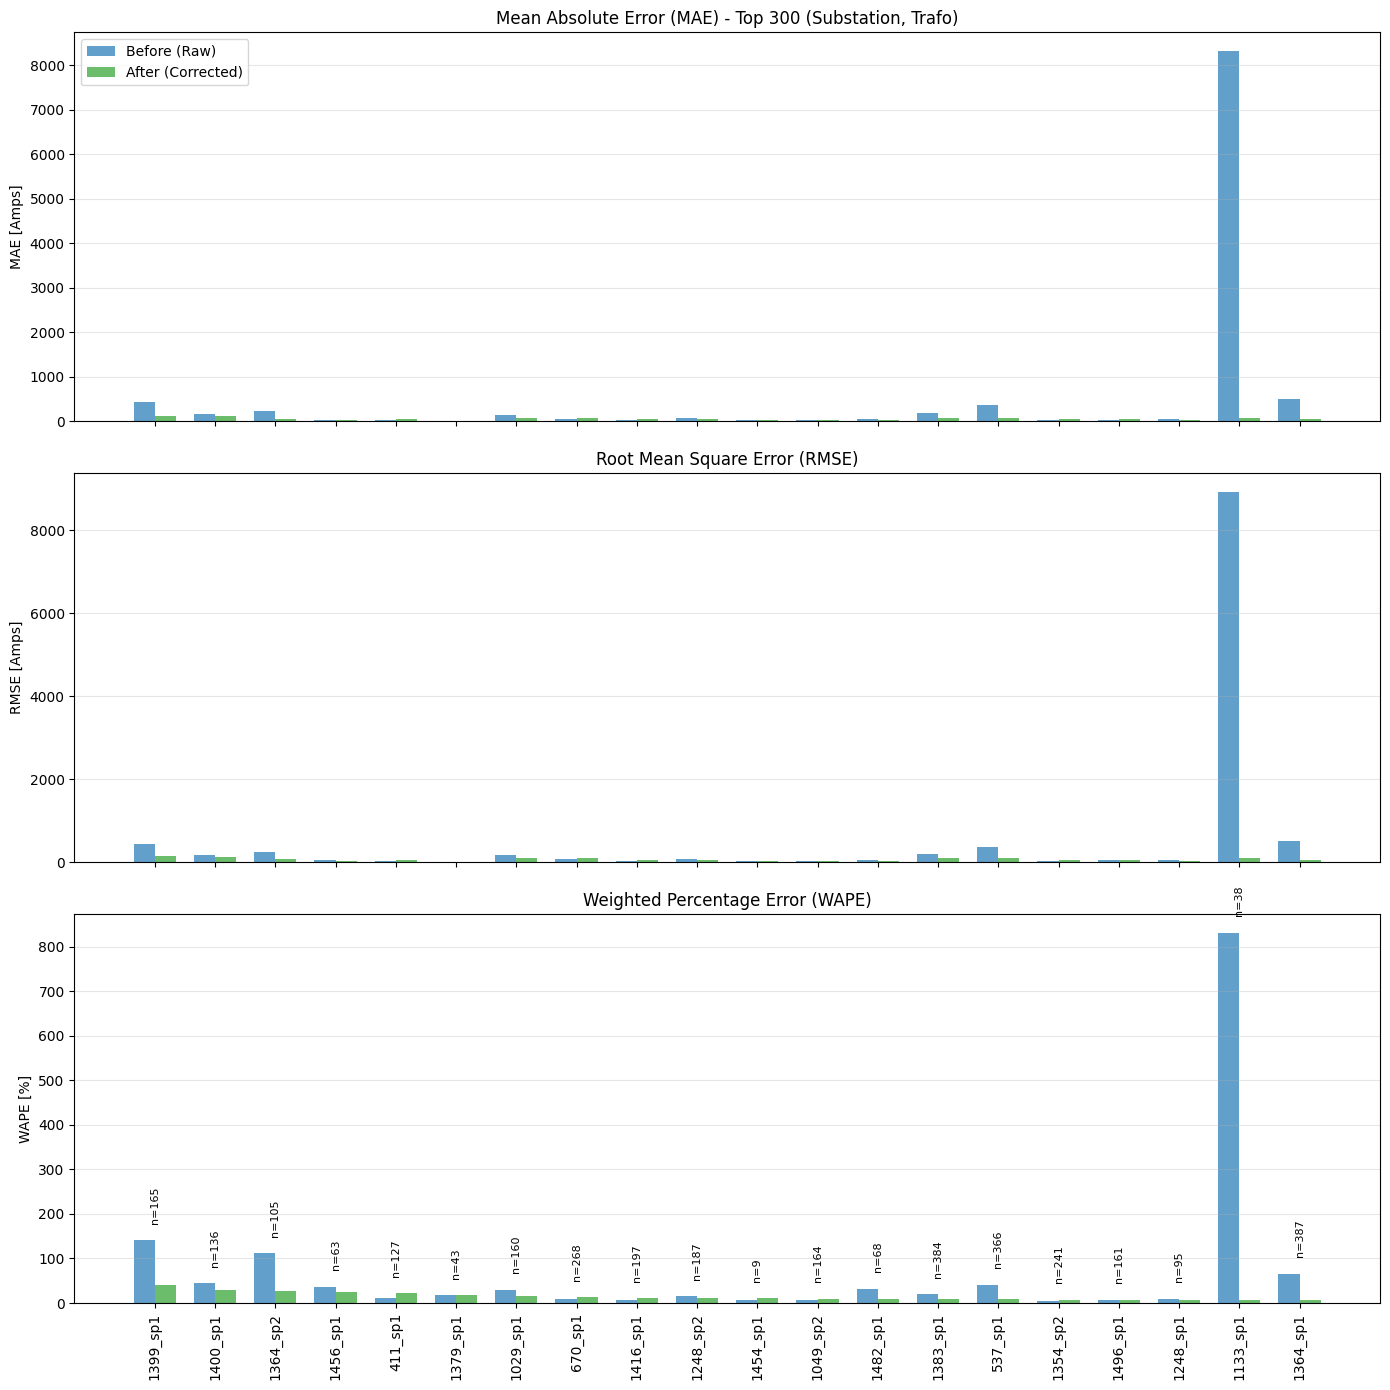

In [ ]:

# ==========================================
# 1. PREPARE DATA (Merged only, no correction yet)
# ==========================================
df_metrics_before = calculate_robust_metrics( df_merged,sm_col="I_total_sm",jn_col="I_total_jn")

# ==========================================
# 2. APPLY CORRECTION & RE-CALCULATE
# ==========================================
df_after = df_merged.copy()

df_after = df_after.merge(
    df_computed[["substation_id", "transformer", "alpha_ct"]],
    on=["substation_id", "transformer"],
    how="left",
)

df_after["alpha_ct"] = df_after["alpha_ct"].fillna(1.0)

# Correct Janitza
df_after["I_total_jn_corr"] = df_after["I_total_jn"] / df_after["alpha_ct"]

# Calculate metrics on corrected data
df_metrics_after = calculate_robust_metrics(
    df_after, 
    sm_col="I_total_sm", 
    jn_col="I_total_jn_corr"
)

# ==========================================
# 3. COMBINE & FILTER
# ==========================================
cutoff = 0.9
min_num = 1

# Filter Index based on coverage
valid_ids = df_metrics_before[
    (df_metrics_before["per_completed"] >= cutoff) & 
    (df_metrics_before["n_mps"] >= min_num)
].index

# Select valid rows
stats_final = pd.DataFrame({
    "MAE_Before": df_metrics_before.loc[valid_ids, "MAE"],
    "MAE_After":  df_metrics_after.loc[valid_ids, "MAE"],
    
    "WAPE_Before": df_metrics_before.loc[valid_ids, "WAPE"],
    "WAPE_After":  df_metrics_after.loc[valid_ids, "WAPE"],
    
    "RMSE_Before": df_metrics_before.loc[valid_ids, "RMSE"],
    "RMSE_After":  df_metrics_after.loc[valid_ids, "RMSE"],
    
    "n_mps": df_metrics_before.loc[valid_ids, "n_mps"]
})

# Sort by Improved WAPE
stats_final = stats_final.sort_values("WAPE_After", ascending=False)

print(stats_final.head())


plot_robust_comparison(stats_final)



Change in the ratio of SMD vs Janitza and after correction

Ratio can be misleading here are stations ploted with old smart meter current and corrected.

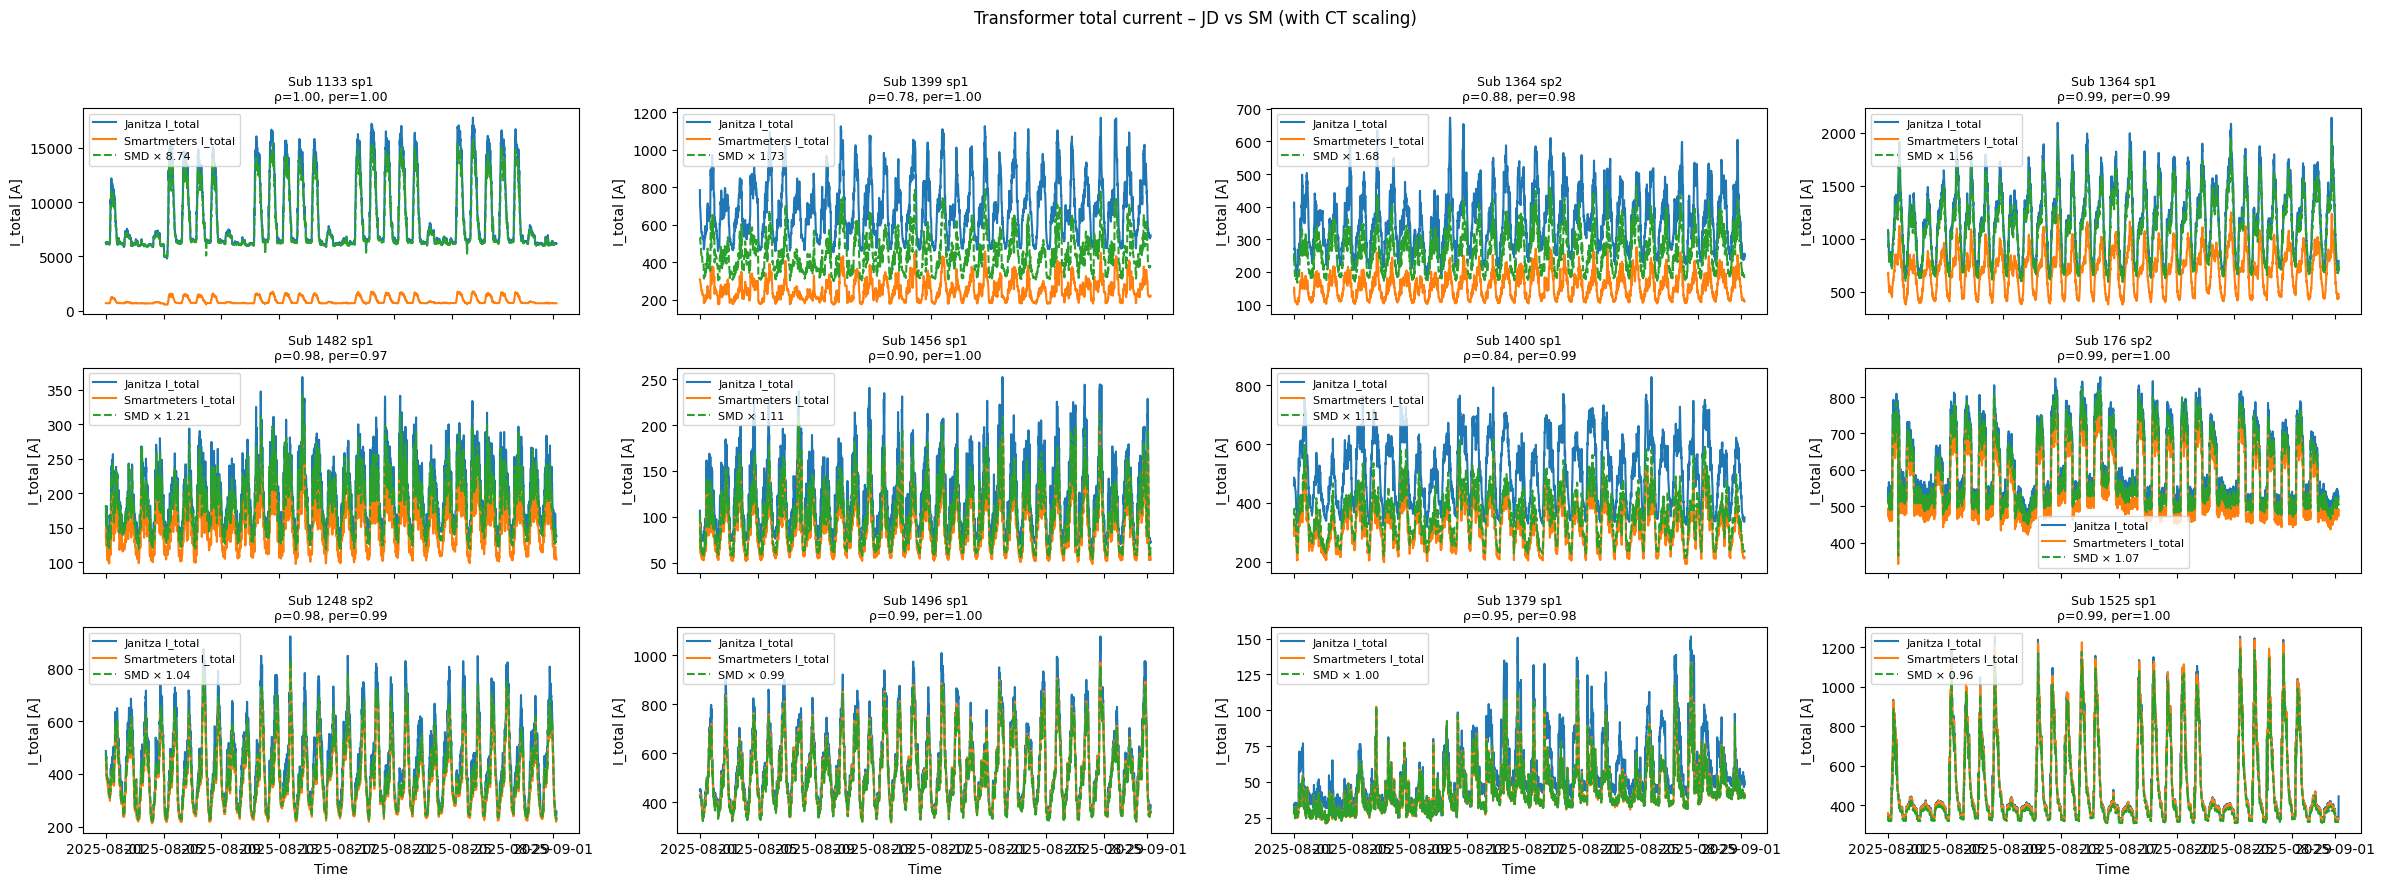

In [ ]:
plot_substation_timeseries_grid(
    merged=df_merged,
    summary=df_computed,
    min_per_completed=0.96,
    max_plots=12,
    cols=4,
    max_points=3000,
)

#maybe look at ljung_box_summary later